# Downstream Analyses on STARmap V1C dataset
Need additional packages: scanpy seaborn networkx

### Load the packages

In [ ]:
%reload_ext autoreload
%autoreload 2

import os
import time
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, f1_score

from Harmonics import *

import warnings
warnings.filterwarnings("ignore")

sc.settings.verbosity = 0
sc.settings.set_figure_params(dpi=50, dpi_save=500)

from matplotlib import rcParams
rcParams["figure.dpi"] = 50
rcParams["savefig.dpi"] = 500
rcParams['pdf.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'
rcParams['ps.fonttype'] = 42
# rcParams['font.family'] = 'Arial'
rcParams['savefig.transparent'] = True

In [2]:
data_dir = '../../../Data/Spatial/Transcriptomics/STARmap_V1_Wang2018/'
save_dir = f'../../results/STARmap_V1_Wang2018/Harmonics/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [3]:
import numpy as np
import pandas as pd
import networkx as nx

def match_cluster_labels(true_labels, est_labels):
    true_labels_arr = np.array(list(true_labels))
    est_labels_arr = np.array(list(est_labels))

    org_cat = list(np.sort(list(pd.unique(true_labels))))
    est_cat = list(np.sort(list(pd.unique(est_labels))))

    B = nx.Graph()
    B.add_nodes_from([i + 1 for i in range(len(org_cat))], bipartite=0)
    B.add_nodes_from([-j - 1 for j in range(len(est_cat))], bipartite=1)

    for i in range(len(org_cat)):
        for j in range(len(est_cat)):
            weight = np.sum((true_labels_arr == org_cat[i]) * (est_labels_arr == est_cat[j]))
            B.add_edge(i + 1, -j - 1, weight=-weight)

    match = nx.algorithms.bipartite.matching.minimum_weight_full_matching(B)

    if len(org_cat) >= len(est_cat):
        return np.array([match[-est_cat.index(c) - 1] - 1 for c in est_labels_arr])
    else:
        unmatched = [c for c in est_cat if not (-est_cat.index(c) - 1) in match.keys()]
        l = []
        for c in est_labels_arr:
            if (-est_cat.index(c) - 1) in match:
                l.append(match[-est_cat.index(c) - 1] - 1)
            else:
                l.append(len(org_cat) + unmatched.index(c))
        return np.array(l)
    
    
def p2stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

Load the result

In [4]:
adata = sc.read_h5ad(save_dir + f'Harmonics_result_0.h5ad')
adata

AnnData object with n_obs × n_vars = 1207 × 1020
    obs: 'clusterid', 'celltype', 'layer', 'slice_name', 'celltype_idx', 'n_neighbors', 'niche_label_jsd', 'niche_label_jsd_v2', 'niche_label_fmi', 'niche_label_ari', 'niche_label_nmi', 'niche_label_asw', 'niche_label_js_asw', 'niche_label_fisher', 'niche_label_chi', 'niche_label_dbi', 'niche_label_dass_min', 'niche_label_dass_mean', 'niche_label_dafisher', 'niche_label_dachi', 'niche_label_0.09', 'niche_label_0.11', 'niche_label_9', 'niche_label_8', 'niche_label_7', 'niche_label_6', 'niche_label_5', 'niche_label_4', 'niche_label_3', 'niche_label_2', 'niche_label'
    uns: 'ct2idx', 'idx2ct', 'niche_cell_count', 'niche_dist', 'niche_label_summary', 'score_dict'
    obsm: 'micro_dist', 'onehot', 'spatial'

### Plot the result

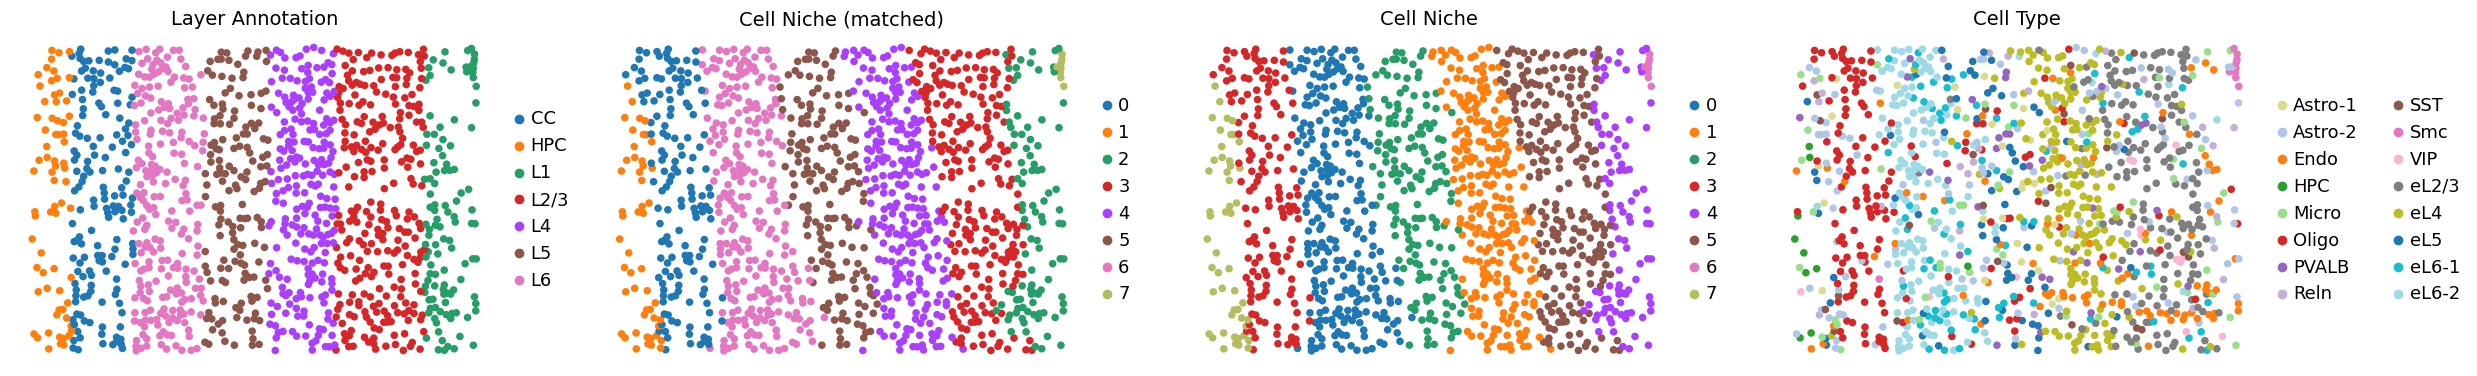

In [5]:
layers = sorted(set(adata.obs['layer'])) 
layer_color_dict = {layers[k]: sns.color_palette()[k] for k in range(len(layers))}

niches = sorted(set(adata.obs['niche_label']))
niche_color_dict = {niches[k]: sns.color_palette()[k] for k in range(len(niches))}

celltypes = ['Astro-1', 'Astro-2', 'Endo', 'HPC', 'Micro', 'Oligo', 'PVALB', 'Reln', 
             'SST', 'Smc', 'VIP', 'eL2/3', 'eL4', 'eL5', 'eL6-1', 'eL6-2']
ct_colors = ['#dbdb8d', '#aec7e8', '#ff7f0e', '#2ca02c', '#98df8a', '#d62728', '#9467bd', '#c5b0d5',
             '#8c564b', '#e377c2', '#f7b6d2', '#7f7f7f', '#bcbd22', '#1f77b4', '#17becf', '#9edae5']
ct_color_dict = {celltypes[k]: ct_colors[k] for k in range(len(celltypes))}


matched_clusters = match_cluster_labels(adata.obs['layer'], adata.obs[f'niche_label'])
matched_labels = [layers[idx] if idx < len(layers) else 'Unmatched' for idx in matched_clusters]
adata.obs[f'matched_cluster'] = [str(label) for label in matched_clusters]
adata.obs[f'matched_label'] = matched_labels

fig, axes = plt.subplots(1, 4, figsize=(25, 4))

sc.pl.embedding(adata, basis='spatial', palette=layer_color_dict, color='layer', 
                ax=axes[0], s=120, show=False, frameon=False, title='Layer Annotation')

sc.pl.embedding(adata, basis='spatial', palette=niche_color_dict, color='matched_cluster', 
                ax=axes[1], s=120, show=False, frameon=False, title='Cell Niche (matched)')

sc.pl.embedding(adata, basis='spatial', palette=niche_color_dict, color='niche_label', 
                ax=axes[2], s=120, show=False, frameon=False, title='Cell Niche')

sc.pl.embedding(adata, basis='spatial', palette=ct_color_dict, color='celltype', 
                ax=axes[3], s=120, show=False, frameon=False, title='Cell Type')

plt.tight_layout()
plt.show()

In [6]:
mapping_df = pd.DataFrame({"matched_cluster": adata.obs["matched_cluster"].values, "niche_label": adata.obs["niche_label"].values})

mapping = mapping_df.groupby("matched_cluster")["niche_label"].agg(lambda x: x.mode().iloc[0]).to_dict()

mapping

{'0': '3',
 '1': '7',
 '2': '4',
 '3': '5',
 '4': '1',
 '5': '2',
 '6': '0',
 '7': '6'}

In [7]:
perm = np.asarray([mapping[i] for i in adata.uns['niche_label_summary']], dtype=int)

niche_labels = adata.uns['niche_label_summary'].copy()
ct_labels = sorted(set(adata.obs['celltype']))
niche_dist = adata.uns['niche_dist'].toarray()[perm].copy()
cell_count_niche = adata.uns['niche_cell_count'][perm].copy()

Calculate the cell type distibution of the original reference annotation

In [8]:
niche_labels_anno = sorted(set(adata.obs['layer']))
niche_dist_anno, cell_count_niche_anno = calculate_distribution(adata.obs['layer'].tolist(), 
                                                                adata.obs['celltype_idx'].tolist(), 
                                                                label_summary=niche_labels_anno, 
                                                                n_niches=len(niche_labels_anno), 
                                                                n_celltypes=len(ct_labels), 
                                                                change2str=True, 
                                                                sparse=False
                                                                )

### Cell type composition

#### Harmonics results

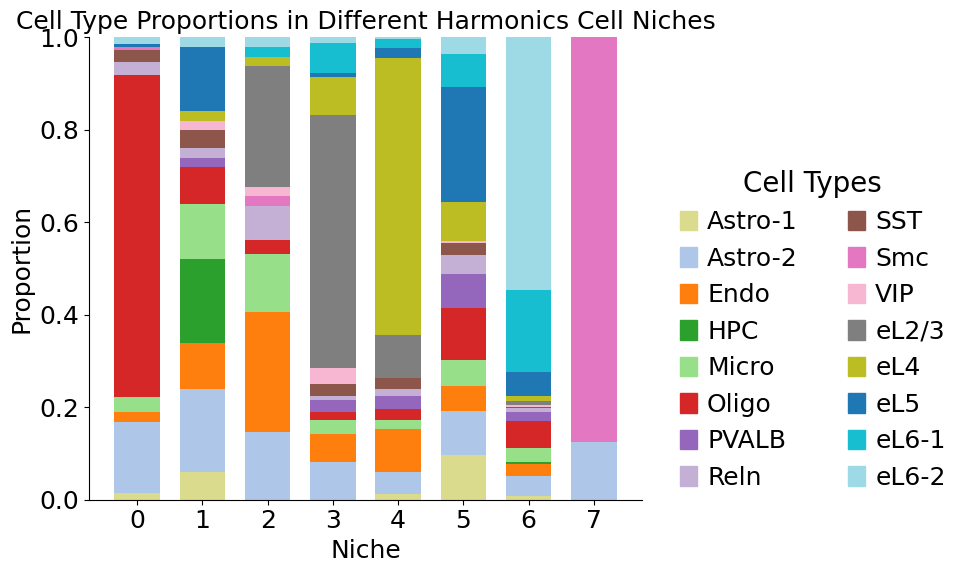

In [9]:
# niche_labels = adata.uns['niche_label_summary'].copy()
# ct_labels = sorted(set(adata.obs['celltype']))
# niche_dist = adata.uns['niche_dist'].toarray().copy()
# cell_count_niche = adata.uns['niche_cell_count'].copy()

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.7
n_niches, n_cell_types = niche_dist.shape

x = np.arange(n_niches)

for j in range(n_cell_types):
    bottom = np.sum(niche_dist[:, :j], axis=1)
    ax.bar(x,                         
           niche_dist[:, j],            
           bottom=bottom,               
           width=bar_width,
           color=ct_color_dict[ct_labels[j]],
           label=ct_labels[j])

ax.set_ylabel('Proportion', fontsize=18)
ax.set_xlabel('Niche', fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(niche_labels, rotation=0, ha='center')
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

handles = [
    mpatches.Patch(color=color, label=ct)
    for ct, color in zip(celltypes, ct_colors)
]

ax.legend(handles=handles, title='Cell Types', loc=(1.05, 0.0), frameon=False, handleheight=0.8, 
          handlelength=0.7, ncol=2, fontsize=18, title_fontsize=20)

plt.title('Cell Type Proportions in Different Harmonics Cell Niches', fontsize=18)
plt.tight_layout()
plt.show()

#### Original annotation

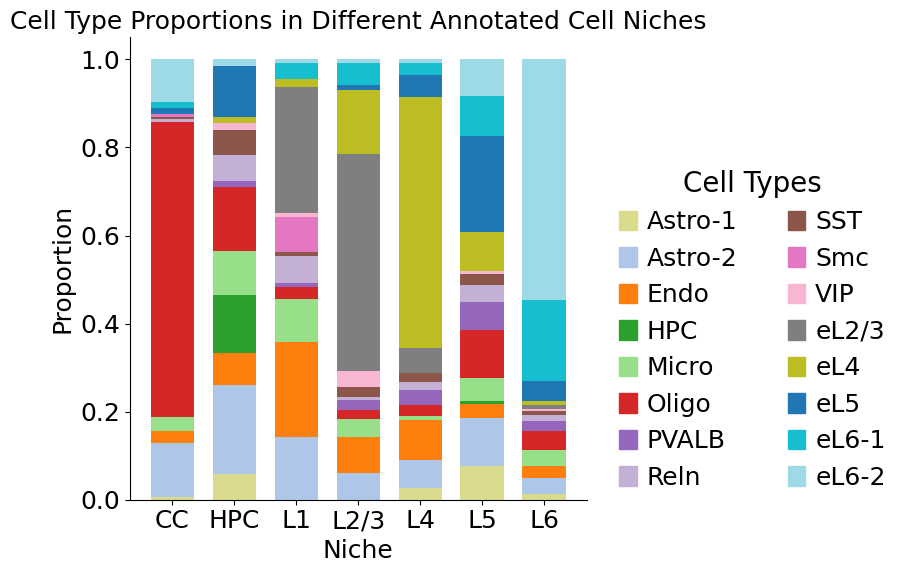

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
bar_width = 0.7
n_niches, n_cell_types = niche_dist_anno.shape

x = np.arange(n_niches)

for j in range(n_cell_types):
    bottom = np.sum(niche_dist_anno[:, :j], axis=1)
    ax.bar(x,                         
           niche_dist_anno[:, j],            
           bottom=bottom,               
           width=bar_width,
           color=ct_color_dict[ct_labels[j]],
           label=ct_labels[j])

ax.set_ylabel('Proportion', fontsize=18)
ax.set_xlabel('Niche', fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(niche_labels_anno, rotation=0, ha='center')
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

handles = [
    mpatches.Patch(color=color, label=ct)
    for ct, color in zip(celltypes, ct_colors)
]

ax.legend(handles=handles, title='Cell Types', loc=(1.05, 0.0), frameon=False, handleheight=0.8, 
          handlelength=0.7, ncol=2, fontsize=18, title_fontsize=20)

plt.title('Cell Type Proportions in Different Annotated Cell Niches', fontsize=18)
plt.tight_layout()
plt.show()

### Cell type enrichment analysis

#### Harmonics results

In [11]:
ct_df = ct_enrichment_test(niche_dist, 
                           cell_count_niche, 
                           adata.uns['idx2ct'],
                           niche_labels,
                           method='fisher', 
                           alpha=0.05, 
                           fdr_method='fdr_by', 
                           log2fc_threshold=1,
                           prop_threshold=0.01,
                           verbose=True,
                           )
ct_df.head()

8 niches and 16 cell types in total.



,niche_idx,niche,celltype_idx,celltype,oddsratio,p-value,q-value,log2fc,prop,enrichment
0,0,0,0,Astro-1,0.590753,0.761000,1.000000,-0.745929,0.013514,False
1,0,0,1,Astro-2,2.192293,0.004430,0.077014,1.005043,0.155405,False
2,0,0,2,Endo,0.243290,0.006042,0.097714,-1.951043,0.020270,False
3,0,0,3,HPC,0.000000,0.620961,1.000000,-26.492722,0.000000,False
4,0,0,4,Micro,0.752864,0.669690,1.000000,-0.393627,0.033784,False


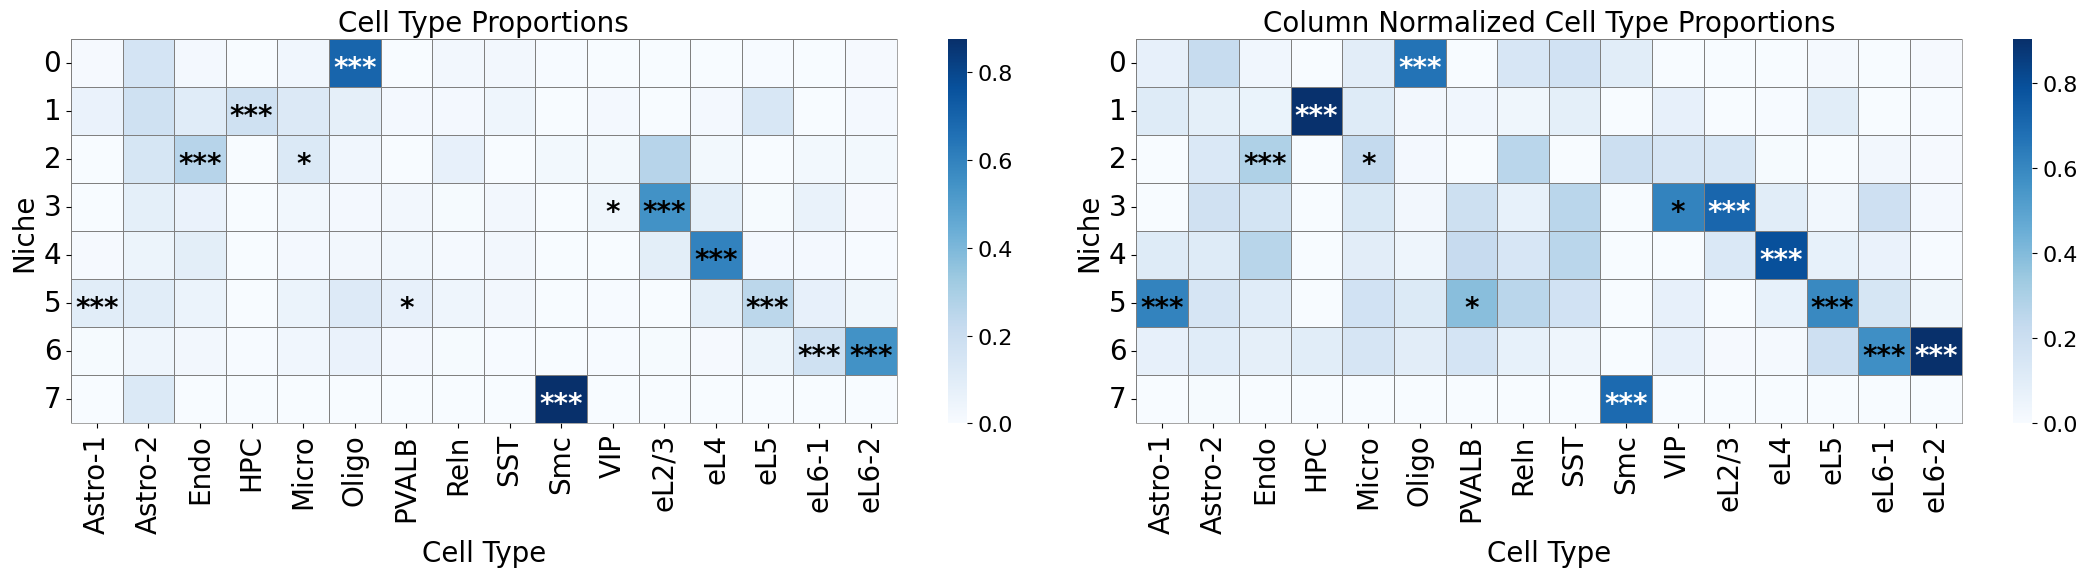

In [12]:
# niche_labels = adata.uns['niche_label_summary'].copy()
# ct_labels = sorted(adata.obs['celltype'].unique())

matrix_df = pd.DataFrame(
    data=niche_dist,
    index=niche_labels,
    columns=ct_labels,
)

cn_dist_count = niche_dist * cell_count_niche[:, np.newaxis]
cn_dist_norm = cn_dist_count / np.sum(cn_dist_count, axis=0)
matrix_df_norm = pd.DataFrame(
    data=cn_dist_norm,
    index=niche_labels,
    columns=ct_labels,
)

ct_df['stars'] = ct_df['q-value'].apply(p2stars)

stars_df = pd.DataFrame(
    '', 
    index=matrix_df.index, 
    columns=matrix_df.columns
)

for _, row in ct_df[ct_df['enrichment']].iterrows():
    niche = row['niche']
    ct    = row['celltype']
    if (niche in stars_df.index) and (ct in stars_df.columns):
        stars_df.loc[niche, ct] = row['stars']


fig, axes = plt.subplots(1, 2, figsize=(22, 6))

sns_heatmap_0 = sns.heatmap(
    matrix_df, 
    cmap='Blues', 
    # cbar_kws={'label': 'Cell type proportion'}, 
    linewidths=0.5,
    linecolor='gray',
    # square=True,
    ax=axes[0]
)

for i, niche in enumerate(matrix_df.index):
    for j, ct in enumerate(matrix_df.columns):
        star = stars_df.iloc[i, j]
        if star:
            if matrix_df.iloc[i, j] > np.max(matrix_df.values) * 0.7:
                color='white'
            else:
                color='black'
            axes[0].text(j + 0.5, i + 0.6, star, ha='center', va='center', color=color, fontsize=20, fontweight='bold')
            if matrix_df_norm.iloc[i, j] > np.max(matrix_df_norm.values) * 0.7:
                color='white'
            else:
                color='black'
            axes[1].text(j + 0.5, i + 0.6, star, ha='center', va='center', color=color, fontsize=20, fontweight='bold')

n_rows, n_cols = matrix_df.shape
axes[0].plot([0, n_cols], [n_rows, n_rows], color='gray', linewidth=0.5, clip_on=False) 
axes[0].plot([n_cols, n_cols], [0, n_rows], color='gray', linewidth=0.5, clip_on=False)  

axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90, ha='center', fontsize=20)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, ha='right', fontsize=20)
axes[0].set_ylabel('Niche', fontsize=20)
axes[0].set_xlabel('Cell Type', fontsize=20)
axes[0].set_title('Cell Type Proportions', fontsize=20)
axes[0].collections[0].colorbar.ax.yaxis.label.set_size(20)
axes[0].collections[0].colorbar.ax.tick_params(labelsize=16)
axes[0].grid(False)

sns_heatmap_1 = sns.heatmap(
    matrix_df_norm, 
    cmap='Blues', 
    # cbar_kws={'label': 'Cell type proportion'}, 
    linewidths=0.5,
    linecolor='gray',
    # square=True,
    ax=axes[1]
)

n_rows, n_cols = matrix_df.shape
axes[1].plot([0, n_cols], [n_rows, n_rows], color='gray', linewidth=0.5, clip_on=False) 
axes[1].plot([n_cols, n_cols], [0, n_rows], color='gray', linewidth=0.5, clip_on=False)  

axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, ha='center', fontsize=20)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, ha='right', fontsize=20)
axes[1].set_ylabel('Niche', fontsize=20)
axes[1].set_xlabel('Cell Type', fontsize=20)
axes[1].set_title('Column Normalized Cell Type Proportions', fontsize=20)
axes[1].collections[0].colorbar.ax.yaxis.label.set_size(20)
axes[1].collections[0].colorbar.ax.tick_params(labelsize=16)
axes[1].grid(False)

plt.tight_layout()
plt.show()

#### Original annotation

In [13]:
ct_df = ct_enrichment_test(niche_dist_anno, 
                           cell_count_niche_anno, 
                           adata.uns['idx2ct'],
                           niche_labels_anno,
                           method='fisher', 
                           alpha=0.05, 
                           fdr_method='fdr_by', 
                           log2fc_threshold=1,
                           prop_threshold=0.01,
                           verbose=True,
                           )
ct_df.head()

7 niches and 16 cell types in total.



,niche_idx,niche,celltype_idx,celltype,oddsratio,p-value,q-value,log2fc,prop,enrichment
0,0,CC,0,Astro-1,0.268758,0.237801,1.000000,-1.870353,0.006494,False
1,0,CC,1,Astro-2,1.582515,0.092399,0.997274,0.595166,0.123377,False
2,0,CC,2,Endo,0.315772,0.017722,0.233776,-1.584049,0.025974,False
3,0,CC,3,HPC,0.000000,0.625329,1.000000,-26.500919,0.000000,False
4,0,CC,4,Micro,0.574611,0.390138,1.000000,-0.459158,0.032468,False


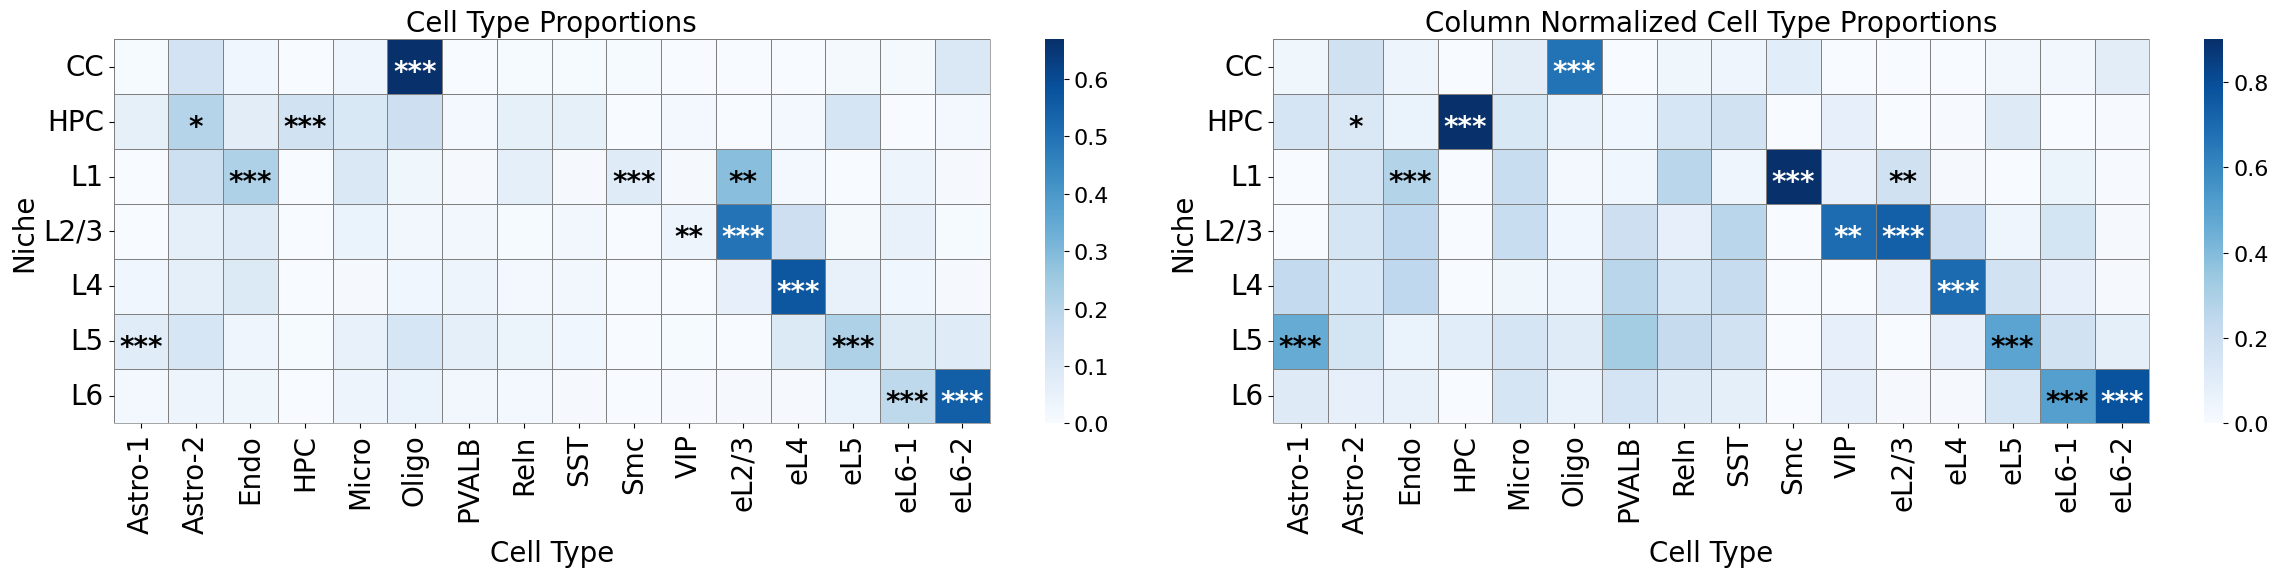

In [14]:
matrix_df = pd.DataFrame(
    data=niche_dist_anno,
    index=niche_labels_anno,
    columns=ct_labels,
)

cn_dist_count = niche_dist_anno * cell_count_niche_anno[:, np.newaxis]
cn_dist_norm = cn_dist_count / np.sum(cn_dist_count, axis=0)
matrix_df_norm = pd.DataFrame(
    data=cn_dist_norm,
    index=niche_labels_anno,
    columns=ct_labels,
)

ct_df['stars'] = ct_df['q-value'].apply(p2stars)

stars_df = pd.DataFrame(
    '', 
    index=matrix_df.index, 
    columns=matrix_df.columns
)

for _, row in ct_df[ct_df['enrichment']].iterrows():
    niche = row['niche']
    ct    = row['celltype']
    if (niche in stars_df.index) and (ct in stars_df.columns):
        stars_df.loc[niche, ct] = row['stars']


fig, axes = plt.subplots(1, 2, figsize=(24, 6))

sns_heatmap_0 = sns.heatmap(
    matrix_df, 
    cmap='Blues', 
    # cbar_kws={'label': 'Cell type proportion'}, 
    linewidths=0.5,
    linecolor='gray',
    # square=True,
    ax=axes[0]
)

for i, niche in enumerate(matrix_df.index):
    for j, ct in enumerate(matrix_df.columns):
        star = stars_df.iloc[i, j]
        if star:
            if matrix_df.iloc[i, j] > np.max(matrix_df.values) * 0.7:
                color='white'
            else:
                color='black'
            axes[0].text(j + 0.5, i + 0.6, star, ha='center', va='center', color=color, fontsize=20, fontweight='bold')
            if matrix_df_norm.iloc[i, j] > np.max(matrix_df_norm.values) * 0.7:
                color='white'
            else:
                color='black'
            axes[1].text(j + 0.5, i + 0.6, star, ha='center', va='center', color=color, fontsize=20, fontweight='bold')

n_rows, n_cols = matrix_df.shape
axes[0].plot([0, n_cols], [n_rows, n_rows], color='gray', linewidth=0.5, clip_on=False) 
axes[0].plot([n_cols, n_cols], [0, n_rows], color='gray', linewidth=0.5, clip_on=False)  

axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90, ha='center', fontsize=20)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, ha='right', fontsize=20)
axes[0].set_ylabel('Niche', fontsize=20)
axes[0].set_xlabel('Cell Type', fontsize=20)
axes[0].set_title('Cell Type Proportions', fontsize=20)
axes[0].collections[0].colorbar.ax.yaxis.label.set_size(20)
axes[0].collections[0].colorbar.ax.tick_params(labelsize=16)
axes[0].grid(False)

sns_heatmap_1 = sns.heatmap(
    matrix_df_norm, 
    cmap='Blues', 
    # cbar_kws={'label': 'Cell type proportion'}, 
    linewidths=0.5,
    linecolor='gray',
    # square=True,
    ax=axes[1]
)

n_rows, n_cols = matrix_df.shape
axes[1].plot([0, n_cols], [n_rows, n_rows], color='gray', linewidth=0.5, clip_on=False) 
axes[1].plot([n_cols, n_cols], [0, n_rows], color='gray', linewidth=0.5, clip_on=False)  

axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, ha='center', fontsize=20)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, ha='right', fontsize=20)
axes[1].set_ylabel('Niche', fontsize=20)
axes[1].set_xlabel('Cell Type', fontsize=20)
axes[1].set_title('Column Normalized Cell Type Proportions', fontsize=20)
axes[1].collections[0].colorbar.ax.yaxis.label.set_size(20)
axes[1].collections[0].colorbar.ax.tick_params(labelsize=16)
axes[1].grid(False)

plt.tight_layout()
plt.show()

### Cell-cell interactions enrichment analysis

#### Harmonics results

In [15]:
cci_results = cci_enrichment_test(adata, 
                                  'matched_cluster', 
                                  'celltype', 
                                  niche_summary=niche_labels, 
                                  spatial_key='spatial', 
                                  cut_percentage=99,
                                  method='fisher', 
                                  alpha=0.05, 
                                  fdr_method='fdr_by', 
                                  log2fc_threshold=1, 
                                  prop_threshold=0.01,
                                  verbose=True,
                                  )
cci_df, test_norm_list, bg_norm_list, test_edge_count_list, bg_edge_count_list = cci_results
cci_df.head()

8 niches and 16 cell types in total.

Testing niche 0...
Testing niche 1...
Testing niche 2...
Testing niche 3...
Testing niche 4...
Testing niche 5...
Testing niche 6...
Testing niche 7...
Finished!


,niche_idx,niche,ct1_idx,ct1,ct2_idx,ct2,test_edge_count,bg_edge_count,test_edge_prop,bg_edge_prop,oddsratio,p-value,q-value,log2fc,enrichment
0,0,0,0,Astro-1,0,Astro-1,0.0,4.0,0.000000,0.001302,0.000000,1.000000,1.000000,-23.633849,False
1,0,0,1,Astro-2,0,Astro-1,3.0,10.0,0.007812,0.003254,2.411811,0.168252,1.000000,1.263504,False
2,0,0,1,Astro-2,1,Astro-2,8.0,22.0,0.020833,0.007159,2.950677,0.013925,0.567743,1.541038,False
3,0,0,2,Endo,0,Astro-1,0.0,13.0,0.000000,0.004230,0.000000,0.384023,1.000000,-25.334289,False
4,0,0,2,Endo,1,Astro-2,3.0,40.0,0.007812,0.013017,0.597047,0.622078,1.000000,-0.736496,False


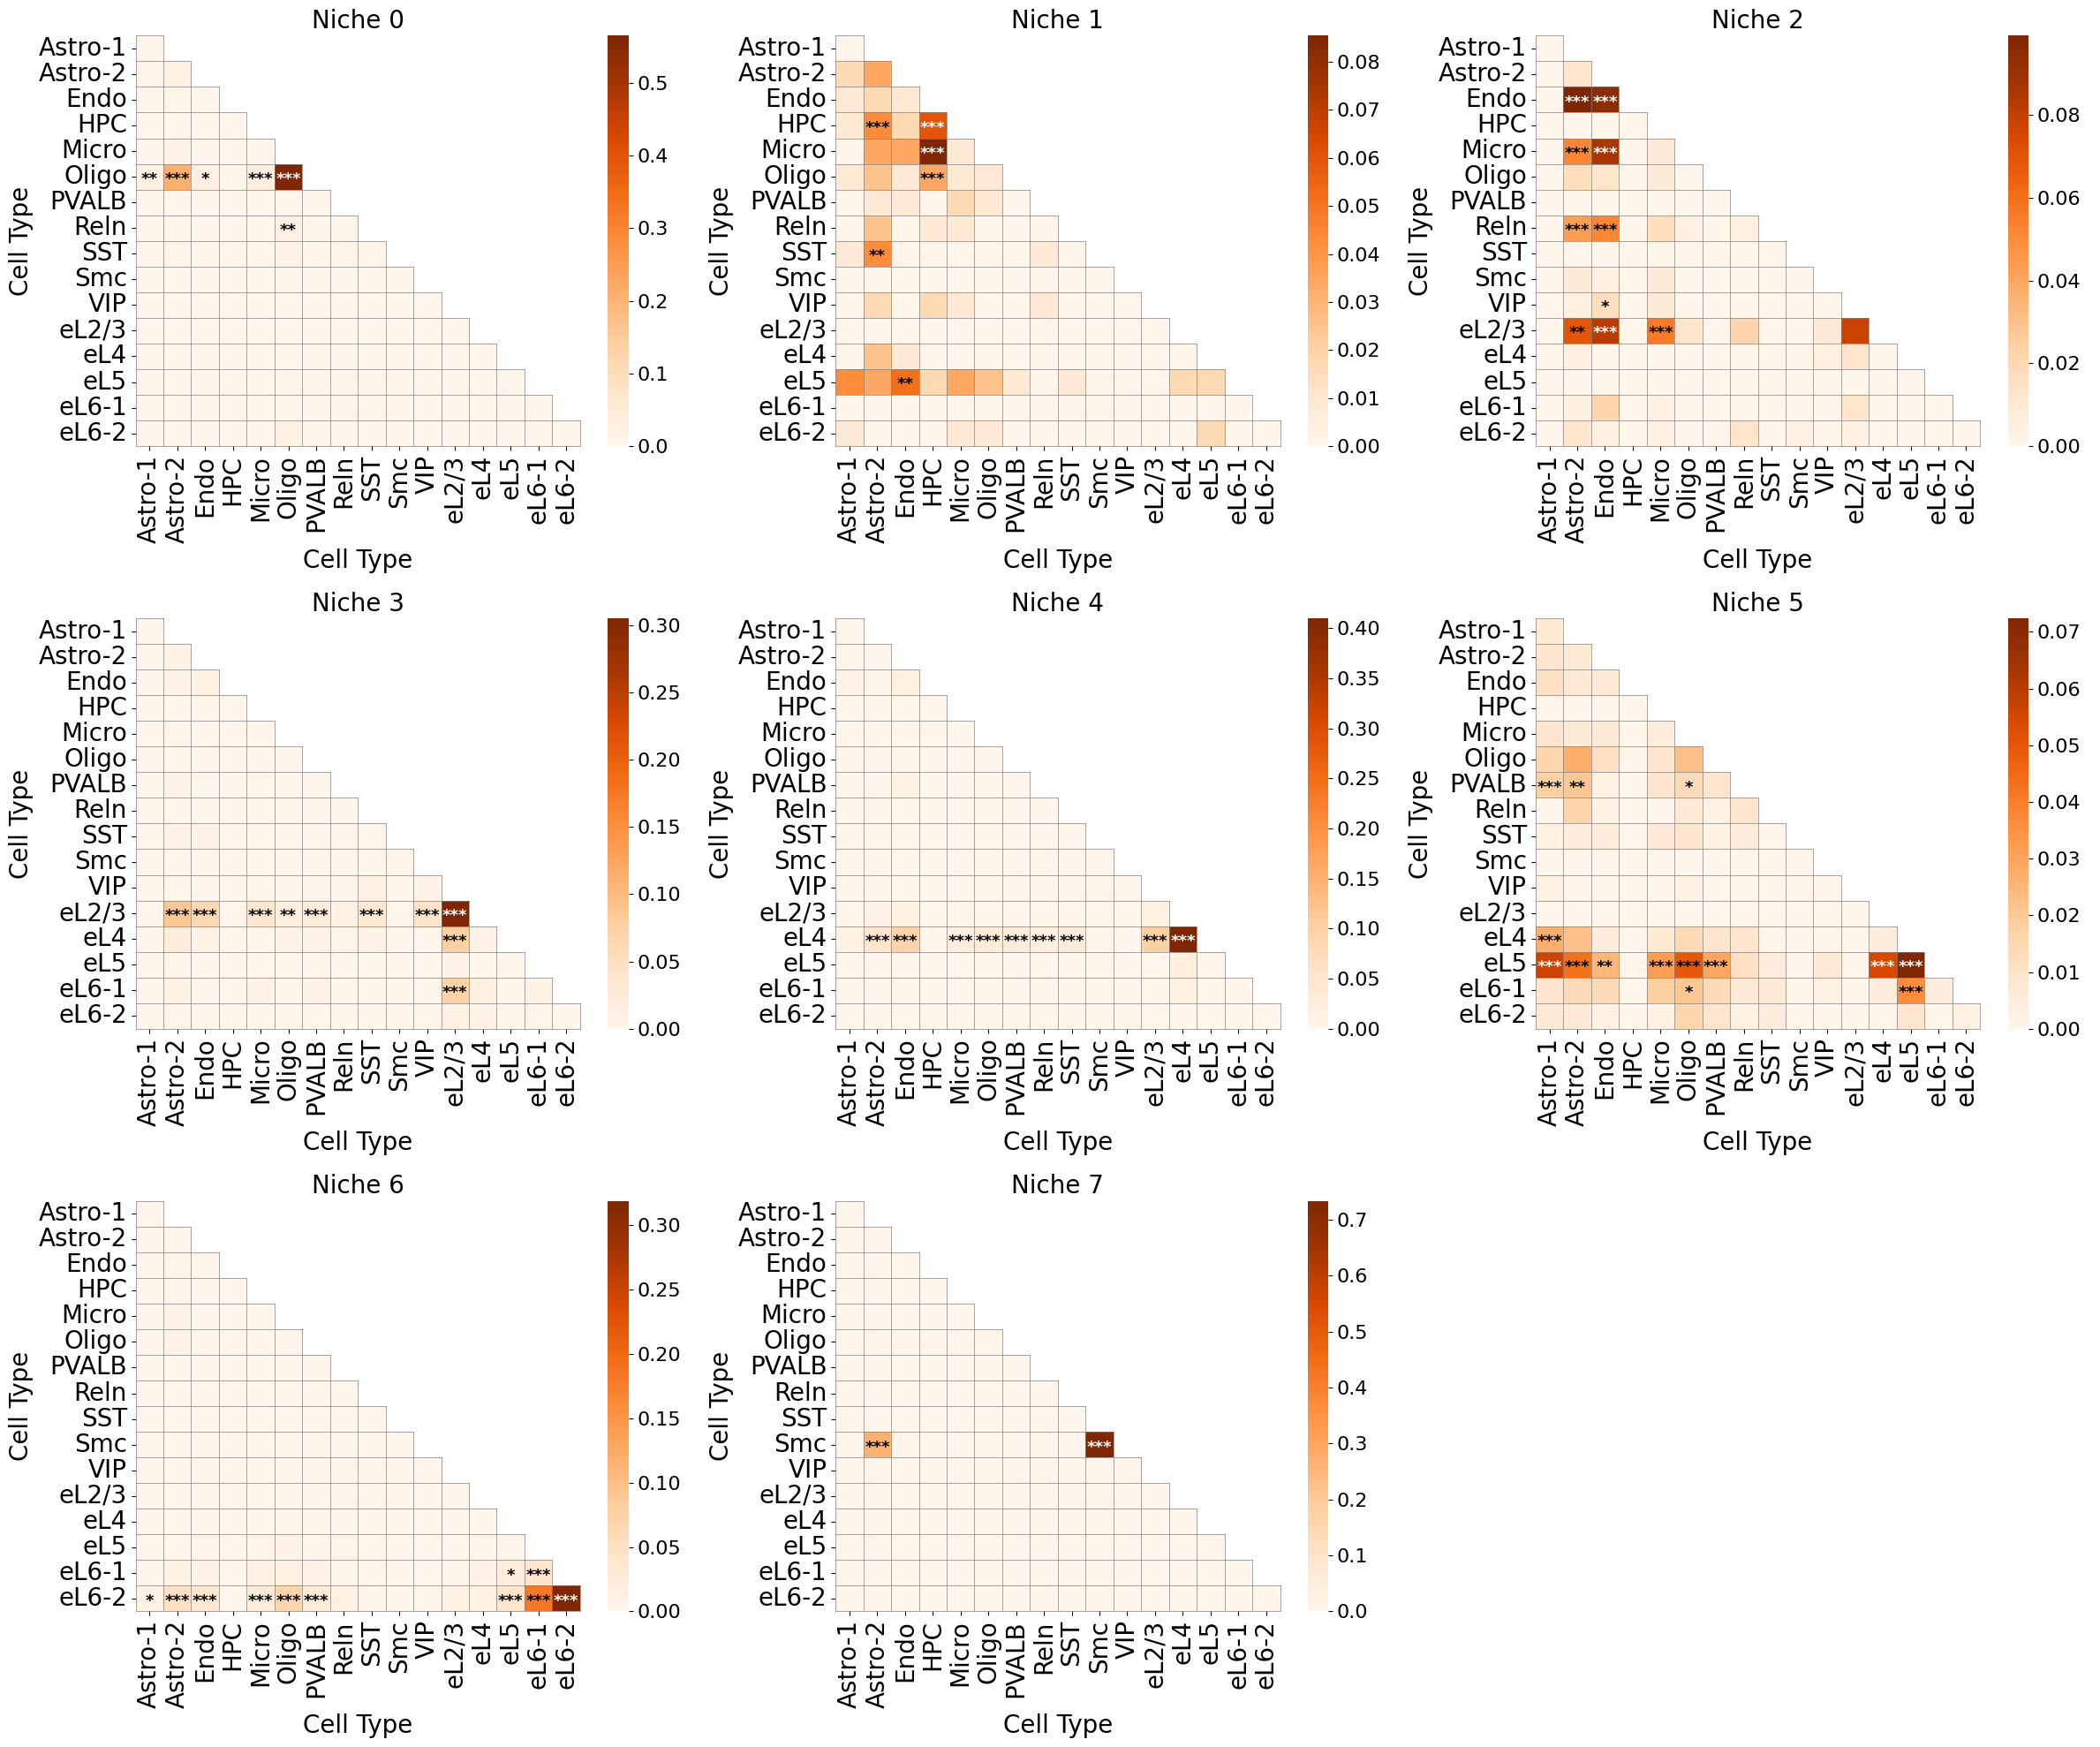

In [16]:
# niche_labels = adata.uns['niche_label_summary'].copy()
# ct_labels = sorted(adata.obs['celltype'].unique())

cci_df['stars'] = cci_df['q-value'].apply(p2stars)

figrows = 3
figcols = 3

fig, axes = plt.subplots(figrows, figcols, figsize=(24, 20))

for idx in range(figrows * figcols):

    imgrow = idx // figcols
    imgcol = idx % figcols

    if idx >= len(niche_labels):
        axes[imgrow, imgcol].axis('off')
        continue

    sub_df = cci_df[cci_df['niche_idx'] == idx]

    matrix_df = pd.DataFrame(
        data=test_norm_list[idx],
        index=ct_labels,
        columns=ct_labels,
    )

    for i in range(matrix_df.shape[0]):
        for j in range(matrix_df.shape[1]):
            if i < j:
                matrix_df.iloc[i, j] = np.nan

    stars_df = pd.DataFrame(
        '', 
        index=matrix_df.index, 
        columns=matrix_df.columns
    )

    for _, row in sub_df[sub_df['enrichment']].iterrows():
        ct1 = row['ct1']
        ct2 = row['ct2']
        if (ct1 in stars_df.index) and (ct2 in stars_df.columns):
            stars_df.loc[ct1, ct2] = row['stars']

    sns_heatmap = sns.heatmap(
        matrix_df, 
        cmap='Oranges', 
        mask=matrix_df.isna(),
        # cbar_kws={'label': 'Edge type proportion'}, 
        # linewidths=0.5,
        # linecolor='gray',
        # square=True,
        ax=axes[imgrow, imgcol],
    )

    n_rows, n_cols = matrix_df.shape

    for i, ct1 in enumerate(matrix_df.index):
        axes[imgrow, imgcol].plot([0, i+1], [i, i], color='gray', linewidth=0.5, clip_on=False) 
        axes[imgrow, imgcol].plot([i+1, i+1], [i, n_rows], color='gray', linewidth=0.5, clip_on=False)
        for j, ct2 in enumerate(matrix_df.columns):
            star = stars_df.iloc[i, j]
            if star:
                if matrix_df.iloc[i, j] > np.nanmax(matrix_df.values) * 0.7:
                    color='white'
                else:
                    color='black'
                axes[imgrow, imgcol].text(j + 0.5, i + 0.6, star, ha='center', va='center', color=color, fontsize=13, fontweight='bold')
    
    axes[imgrow, imgcol].plot([0, 0], [0, n_rows], color='gray', linewidth=0.5, clip_on=False) 
    axes[imgrow, imgcol].plot([0, n_cols], [n_rows, n_rows], color='gray', linewidth=0.5, clip_on=False)  
    # axes[imgrow, imgcol].plot([0, n_cols], [n_rows, n_rows], color='gray', linewidth=0.5, clip_on=False) 
    # axes[imgrow, imgcol].plot([n_cols, n_cols], [0, n_rows], color='gray', linewidth=0.5, clip_on=False)  

    axes[imgrow, imgcol].set_xticklabels(axes[imgrow, imgcol].get_xticklabels(), rotation=90, ha='center', fontsize=20)
    axes[imgrow, imgcol].set_yticklabels(axes[imgrow, imgcol].get_yticklabels(), rotation=0, ha='right', fontsize=20)
    axes[imgrow, imgcol].set_ylabel('Cell Type', fontsize=20)
    axes[imgrow, imgcol].set_xlabel('Cell Type', fontsize=20)
    axes[imgrow, imgcol].set_title(f'Niche {niche_labels[idx]}', fontsize=20)
    axes[imgrow, imgcol].collections[0].colorbar.ax.yaxis.label.set_size(20)
    axes[imgrow, imgcol].collections[0].colorbar.ax.tick_params(labelsize=16)
    axes[imgrow, imgcol].grid(False)

plt.tight_layout()
plt.show()

#### Original annotation

In [17]:
cci_results = cci_enrichment_test(adata, 
                                  'layer', 
                                  'celltype', 
                                  niche_summary=niche_labels_anno, 
                                  spatial_key='spatial', 
                                  cut_percentage=99,
                                  method='fisher', 
                                  alpha=0.05, 
                                  fdr_method='fdr_by', 
                                  log2fc_threshold=1, 
                                  prop_threshold=0.01,
                                  verbose=True,
                                  )
cci_df, test_norm_list, bg_norm_list, test_edge_count_list, bg_edge_count_list = cci_results
cci_df.head()

7 niches and 16 cell types in total.

Testing niche CC...
Testing niche HPC...
Testing niche L1...
Testing niche L2/3...
Testing niche L4...
Testing niche L5...
Testing niche L6...
Finished!


,niche_idx,niche,ct1_idx,ct1,ct2_idx,ct2,test_edge_count,bg_edge_count,test_edge_prop,bg_edge_prop,oddsratio,p-value,q-value,log2fc,enrichment
0,0,CC,0,Astro-1,0,Astro-1,0.0,4.0,0.000000,0.001311,0.000000,1.000000,1.0,-23.644688,False
1,0,CC,1,Astro-2,0,Astro-1,1.0,14.0,0.002519,0.004590,0.547619,1.000000,1.0,-0.865757,False
2,0,CC,1,Astro-2,1,Astro-2,5.0,25.0,0.012594,0.008197,1.543367,0.382582,1.0,0.619670,False
3,0,CC,2,Endo,0,Astro-1,0.0,13.0,0.000000,0.004262,0.000000,0.384975,1.0,-25.345127,False
4,0,CC,2,Endo,1,Astro-2,4.0,40.0,0.010076,0.013115,0.765903,0.812580,1.0,-0.380330,False


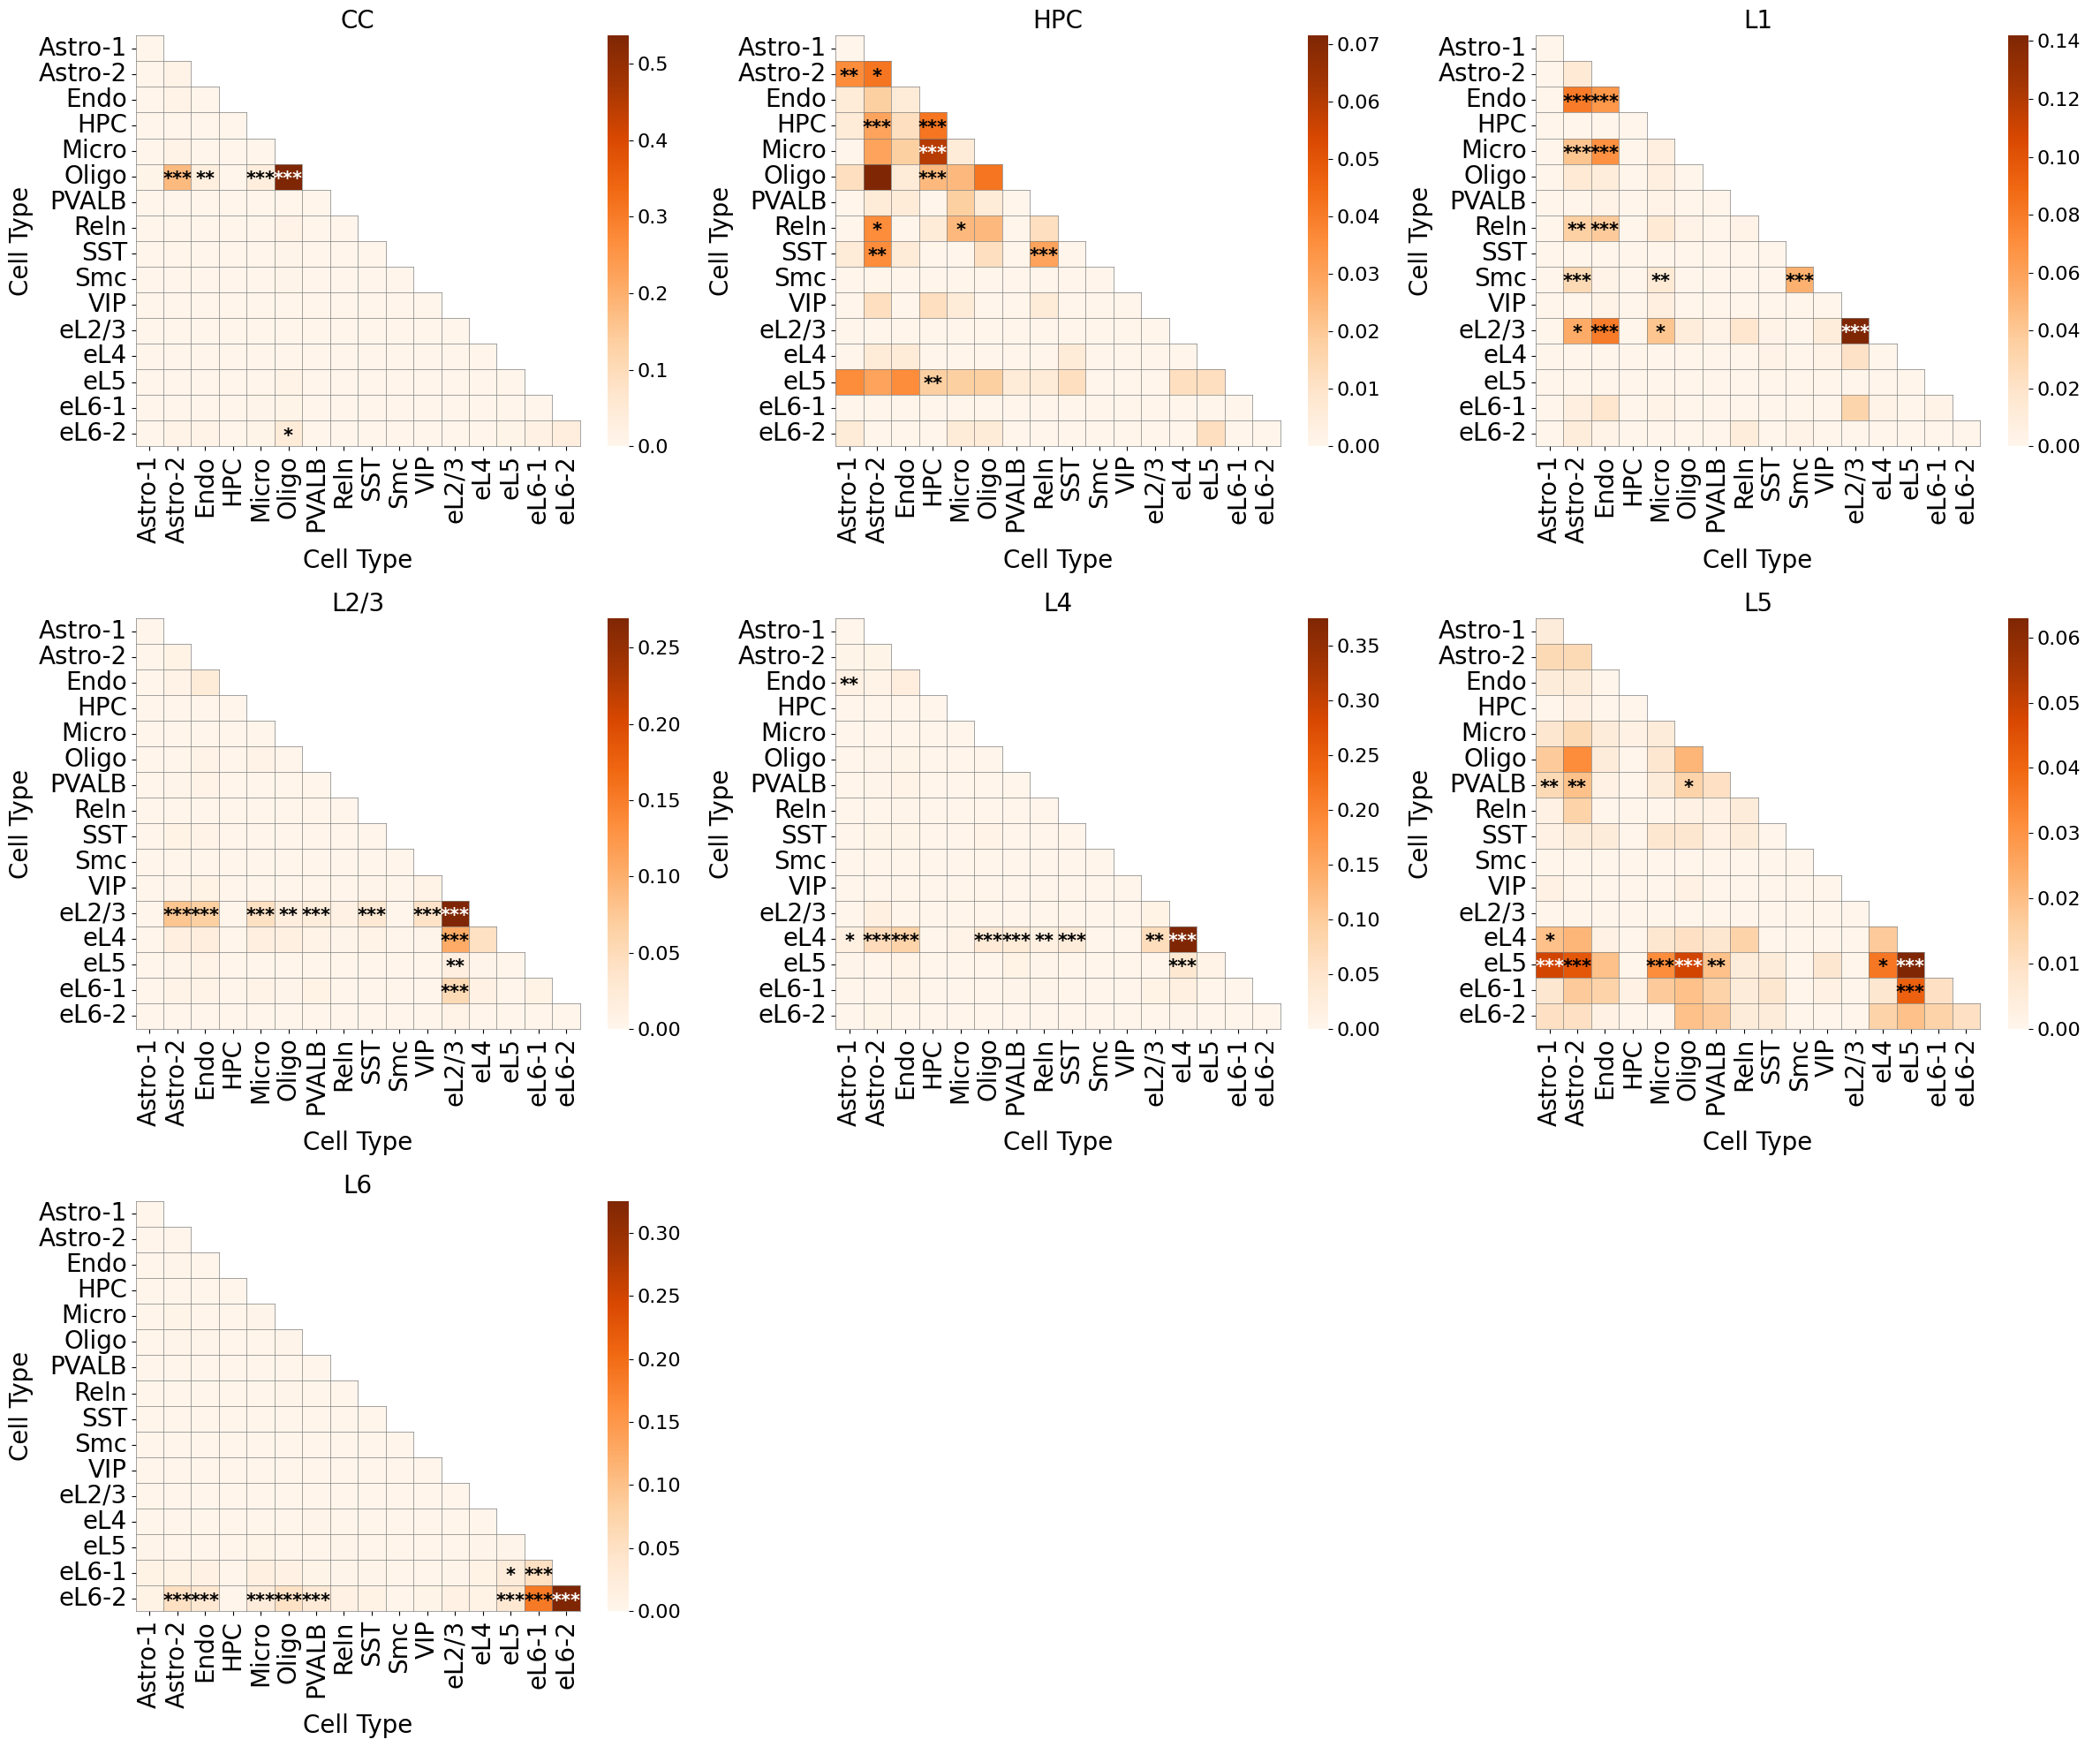

In [18]:
cci_df['stars'] = cci_df['q-value'].apply(p2stars)

figrows = 3
figcols = 3

fig, axes = plt.subplots(figrows, figcols, figsize=(24, 20))

for idx in range(figrows * figcols):

    imgrow = idx // figcols
    imgcol = idx % figcols

    if idx >= len(niche_labels_anno):
        axes[imgrow, imgcol].axis('off')
        continue

    sub_df = cci_df[cci_df['niche_idx'] == idx]

    matrix_df = pd.DataFrame(
        data=test_norm_list[idx],
        index=ct_labels,
        columns=ct_labels,
    )

    for i in range(matrix_df.shape[0]):
        for j in range(matrix_df.shape[1]):
            if i < j:
                matrix_df.iloc[i, j] = np.nan

    stars_df = pd.DataFrame(
        '', 
        index=matrix_df.index, 
        columns=matrix_df.columns
    )

    for _, row in sub_df[sub_df['enrichment']].iterrows():
        ct1 = row['ct1']
        ct2 = row['ct2']
        if (ct1 in stars_df.index) and (ct2 in stars_df.columns):
            stars_df.loc[ct1, ct2] = row['stars']

    sns_heatmap = sns.heatmap(
        matrix_df, 
        cmap='Oranges', 
        mask=matrix_df.isna(),
        # cbar_kws={'label': 'Edge type proportion'}, 
        # linewidths=0.5,
        # linecolor='gray',
        # square=True,
        ax=axes[imgrow, imgcol],
    )

    n_rows, n_cols = matrix_df.shape

    for i, ct1 in enumerate(matrix_df.index):
        axes[imgrow, imgcol].plot([0, i+1], [i, i], color='gray', linewidth=0.5, clip_on=False) 
        axes[imgrow, imgcol].plot([i+1, i+1], [i, n_rows], color='gray', linewidth=0.5, clip_on=False)
        for j, ct2 in enumerate(matrix_df.columns):
            star = stars_df.iloc[i, j]
            if star:
                if matrix_df.iloc[i, j] > np.nanmax(matrix_df.values) * 0.7:
                    color='white'
                else:
                    color='black'
                axes[imgrow, imgcol].text(j + 0.5, i + 0.6, star, ha='center', va='center', color=color, fontsize=15, fontweight='bold')
    
    axes[imgrow, imgcol].plot([0, 0], [0, n_rows], color='gray', linewidth=0.5, clip_on=False) 
    axes[imgrow, imgcol].plot([0, n_cols], [n_rows, n_rows], color='gray', linewidth=0.5, clip_on=False)  
    # axes[imgrow, imgcol].plot([0, n_cols], [n_rows, n_rows], color='gray', linewidth=0.5, clip_on=False) 
    # axes[imgrow, imgcol].plot([n_cols, n_cols], [0, n_rows], color='gray', linewidth=0.5, clip_on=False)  

    axes[imgrow, imgcol].set_xticklabels(axes[imgrow, imgcol].get_xticklabels(), rotation=90, ha='center', fontsize=20)
    axes[imgrow, imgcol].set_yticklabels(axes[imgrow, imgcol].get_yticklabels(), rotation=0, ha='right', fontsize=20)
    axes[imgrow, imgcol].set_ylabel('Cell Type', fontsize=20)
    axes[imgrow, imgcol].set_xlabel('Cell Type', fontsize=20)
    axes[imgrow, imgcol].set_title(f'{niche_labels_anno[idx]}', fontsize=20)
    axes[imgrow, imgcol].collections[0].colorbar.ax.yaxis.label.set_size(20)
    axes[imgrow, imgcol].collections[0].colorbar.ax.tick_params(labelsize=16)
    axes[imgrow, imgcol].grid(False)

plt.tight_layout()
plt.show()

### Niche-niche co-localization analysis

#### Harmonics results

In [19]:
nnc_results = nnc_enrichment_test(adata, 
                                  'matched_cluster', 
                                  niche_summary=niche_labels,  
                                  spatial_key='spatial', 
                                  cut_percentage=99, 
                                  method='fisher', 
                                  alpha=0.05, 
                                  fdr_method='fdr_by', 
                                  log2fc_threshold=1, 
                                  prop_threshold=0.01,
                                  verbose=True,
                                  )
nnc_df, edge_prop_mtx, n1_count = nnc_results
nnc_df.head()

8 niches in total.



,niche1_idx,niche1,niche2_idx,niche2,edge_count,edge_prop,oddsratio,p-value,q-value,log2fc,enrichment
0,0,0,1,1,51.0,0.485714,inf,6.284496e-49,4.057306e-47,32.177461,True
1,0,0,2,2,0.0,0.000000,0.0,8.067845e-07,6.510809e-06,-30.385802,False
2,0,0,3,3,0.0,0.000000,0.0,3.235591e-11,5.222291e-10,-31.078479,False
3,0,0,4,4,0.0,0.000000,0.0,1.123692e-09,1.319022e-08,-30.878401,False
4,0,0,5,5,0.0,0.000000,0.0,1.937610e-08,1.924511e-07,-30.673783,False


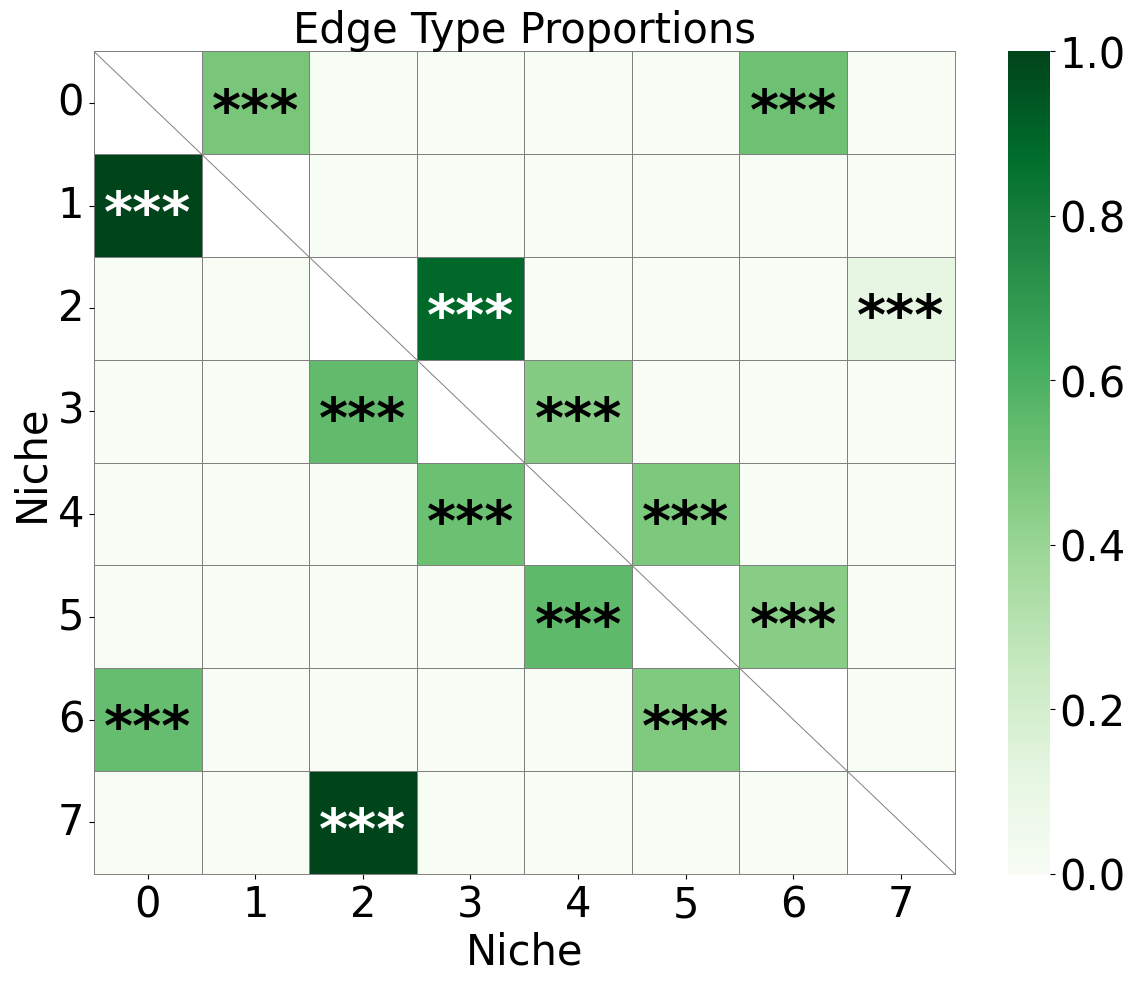

In [20]:
# niche_labels = adata.uns['niche_label_summary'].copy()

nnc_df['stars'] = nnc_df['q-value'].apply(p2stars)

matrix_df = pd.DataFrame(
    data=edge_prop_mtx,
    index=niche_labels,
    columns=niche_labels,
)

for i in range(matrix_df.shape[0]):
    for j in range(matrix_df.shape[1]):
        if i == j:
            matrix_df.iloc[i, j] = np.nan

stars_df = pd.DataFrame(
    '', 
    index=matrix_df.index, 
    columns=matrix_df.columns
)

for _, row in nnc_df[nnc_df['enrichment']].iterrows():
    n1 = row['niche1']
    n2 = row['niche2']
    if (n1 in stars_df.index) and (n2 in stars_df.columns):
        stars_df.loc[n1, n2] = row['stars']

plt.figure(figsize=(12, 10))

ax  = sns.heatmap(
    matrix_df, 
    cmap='Greens', 
    # cbar_kws={'label': 'Edge type proportion'}, 
    linewidths=0.7,
    linecolor='gray',
    # square=True,
)

for i, n1 in enumerate(matrix_df.index):
    for j, n2 in enumerate(matrix_df.columns):
        if i == j:
            ax.plot([i, i+1], [i, i+1], color='gray', linewidth=0.7)
            # ax.plot([i+1, i], [i, i+1], color='gray', linewidth=0.7)
            continue
        star = stars_df.iloc[i, j]
        if star:
            if matrix_df.iloc[i, j] > np.nanmax(matrix_df.values) * 0.7:
                color='white'
            else:
                color='black'
            ax.text(j + 0.5, i + 0.6, star, ha='center', va='center', color=color, fontsize=40, fontweight='bold')

n_rows, n_cols = matrix_df.shape
ax.plot([0, n_cols], [n_rows, n_rows], color='gray', linewidth=0.7, clip_on=False) 
ax.plot([n_cols, n_cols], [0, n_rows], color='gray', linewidth=0.7, clip_on=False)  

ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=30)
ax.set_ylabel('Niche', fontsize=30)
ax.set_xlabel('Niche', fontsize=30)
ax.set_title('Edge Type Proportions', fontsize=30)
ax.collections[0].colorbar.ax.yaxis.label.set_size(30)
ax.collections[0].colorbar.ax.tick_params(labelsize=30)
ax.grid(False)

plt.tight_layout()
plt.show()

#### Original annotation

In [21]:
nnc_results = nnc_enrichment_test(adata, 
                                  'layer', 
                                  niche_summary=niche_labels_anno,  
                                  spatial_key='spatial', 
                                  cut_percentage=99, 
                                  method='fisher', 
                                  alpha=0.05, 
                                  fdr_method='fdr_by', 
                                  log2fc_threshold=1, 
                                  prop_threshold=0.01,
                                  verbose=True,
                                  )
nnc_df, edge_prop_mtx, n1_count = nnc_results
nnc_df.head()

7 niches in total.



,niche1_idx,niche1,niche2_idx,niche2,edge_count,edge_prop,oddsratio,p-value,q-value,log2fc,enrichment
0,0,CC,1,HPC,56.0,0.486957,inf,2.621345e-50,1.190898e-48,32.181146,True
1,0,CC,2,L1,0.0,0.000000,0.0,9.655021e-06,5.848471e-05,-30.056890,False
2,0,CC,3,L2/3,0.0,0.000000,0.0,9.008227e-12,1.169288e-10,-31.045574,False
3,0,CC,4,L4,0.0,0.000000,0.0,3.146870e-10,2.859296e-09,-30.851305,False
4,0,CC,5,L5,0.0,0.000000,0.0,3.282007e-09,2.485070e-08,-30.729315,False


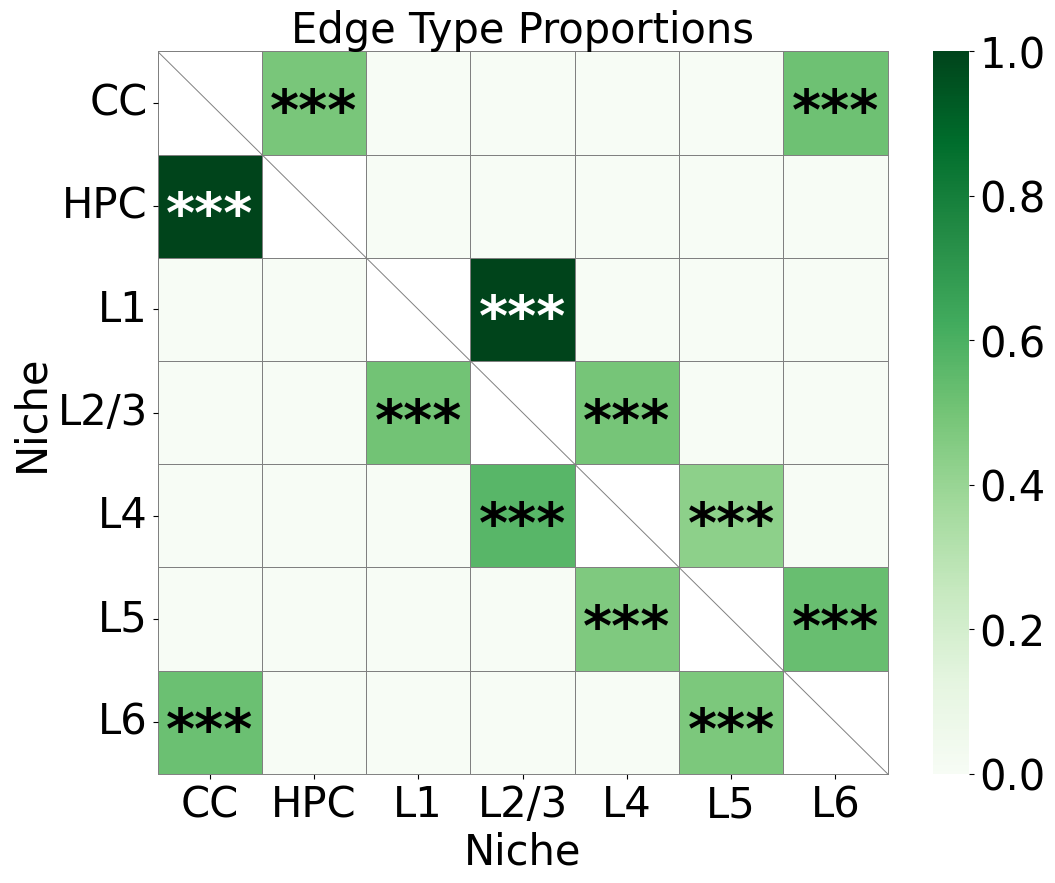

In [22]:
nnc_df['stars'] = nnc_df['q-value'].apply(p2stars)

matrix_df = pd.DataFrame(
    data=edge_prop_mtx,
    index=niche_labels_anno,
    columns=niche_labels_anno,
)

for i in range(matrix_df.shape[0]):
    for j in range(matrix_df.shape[1]):
        if i == j:
            matrix_df.iloc[i, j] = np.nan

stars_df = pd.DataFrame(
    '', 
    index=matrix_df.index, 
    columns=matrix_df.columns
)

for _, row in nnc_df[nnc_df['enrichment']].iterrows():
    n1 = row['niche1']
    n2 = row['niche2']
    if (n1 in stars_df.index) and (n2 in stars_df.columns):
        stars_df.loc[n1, n2] = row['stars']

plt.figure(figsize=(11, 9))

ax  = sns.heatmap(
    matrix_df, 
    cmap='Greens', 
    # cbar_kws={'label': 'Edge type proportion'}, 
    linewidths=0.7,
    linecolor='gray',
    # square=True,
)

for i, n1 in enumerate(matrix_df.index):
    for j, n2 in enumerate(matrix_df.columns):
        if i == j:
            ax.plot([i, i+1], [i, i+1], color='gray', linewidth=0.7)
            # ax.plot([i+1, i], [i, i+1], color='gray', linewidth=0.7)
            continue
        star = stars_df.iloc[i, j]
        if star:
            if matrix_df.iloc[i, j] > np.nanmax(matrix_df.values) * 0.7:
                color='white'
            else:
                color='black'
            ax.text(j + 0.5, i + 0.6, star, ha='center', va='center', color=color, fontsize=40, fontweight='bold')

n_rows, n_cols = matrix_df.shape
ax.plot([0, n_cols], [n_rows, n_rows], color='gray', linewidth=0.7, clip_on=False) 
ax.plot([n_cols, n_cols], [0, n_rows], color='gray', linewidth=0.7, clip_on=False)  

ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=30)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=30)
ax.set_ylabel('Niche', fontsize=30)
ax.set_xlabel('Niche', fontsize=30)
ax.set_title('Edge Type Proportions', fontsize=30)
ax.collections[0].colorbar.ax.yaxis.label.set_size(30)
ax.collections[0].colorbar.ax.tick_params(labelsize=30)
ax.grid(False)

plt.tight_layout()
plt.show()

### Comparison of Harmonics results with original annotation

#### Cell type purity / recall / F1 score

In [23]:
def purity_recall_f1_scores(adata, celltype_key, niche_key, ct, niche):

    ct_mask = adata.obs[celltype_key] == ct
    niche_mask = adata.obs[niche_key] == niche

    TP = (ct_mask & niche_mask).sum()
    niche_size = niche_mask.sum()
    ct_size = ct_mask.sum()

    # precision / purity
    purity = TP / niche_size if niche_size > 0 else 0.0

    # recall
    recall = TP / ct_size if ct_size > 0 else 0.0

    # F1 score
    if purity + recall > 0:
        f1 = 2 * purity * recall / (purity + recall)
    else:
        f1 = 0.0

    return purity, recall, f1


excitatory_cts = ['HPC', 'eL2/3', 'eL4', 'eL5', 'eL6-1', 'eL6-2']
inhibitory_cts = ['PVALB', 'Reln', 'SST', 'VIP']
nn_cts = ['Astro-1', 'Astro-2', 'Endo', 'Micro', 'Oligo', 'Smc']

layers_anno = ['HPC', 'L2/3', 'L4', 'L5', 'L6']
niches_Harmonics = ['1', '3', '4', '5', '6']

ct_to_layer = {
    'HPC': 'HPC',
    'eL2/3': 'L2/3',
    'eL4': 'L4',
    'eL5': 'L5',
    'eL6-1': 'L6',
    'eL6-2': 'L6',
}

ct_to_niche = {
    'HPC': '1',
    'eL2/3': '3',
    'eL4': '4',
    'eL5': '5',
    'eL6-1': '6',
    'eL6-2': '6',
}

records = []

for ct in excitatory_cts:

    layer = ct_to_layer[ct]
    p_anno, r_anno, f1_anno = purity_recall_f1_scores(adata, celltype_key='celltype', niche_key='layer', ct=ct, niche=layer)

    niche = ct_to_niche[ct]
    p_Harmonics, r_Harmonics, f1_Harmonics = purity_recall_f1_scores(adata, celltype_key='celltype', niche_key='matched_cluster', ct=ct, niche=niche)

    records.append({'celltype': ct, 'Method': 'Annotation', 'Purity': p_anno, 'Recall': r_anno, 'F1-score': f1_anno})
    records.append({'celltype': ct, 'Method': 'Harmonics', 'Purity': p_Harmonics, 'Recall': r_Harmonics, 'F1-score': f1_Harmonics})

df = pd.DataFrame(records)
df

,celltype,Method,Purity,Recall,F1-score
0,HPC,Annotation,0.130435,0.900000,0.227848
1,HPC,Harmonics,0.180000,0.900000,0.300000
2,eL2/3,Annotation,0.494253,0.732955,0.590389
3,eL2/3,Harmonics,0.545455,0.715909,0.619165
4,eL4,Annotation,0.568966,0.698413,0.627078
5,eL4,Harmonics,0.600000,0.793651,0.683371
6,eL5,Annotation,0.217949,0.492754,0.302222
7,eL5,Harmonics,0.246988,0.594203,0.348936
8,eL6-1,Annotation,0.183857,0.512500,0.270627
9,eL6-1,Harmonics,0.178295,0.575000,0.272189


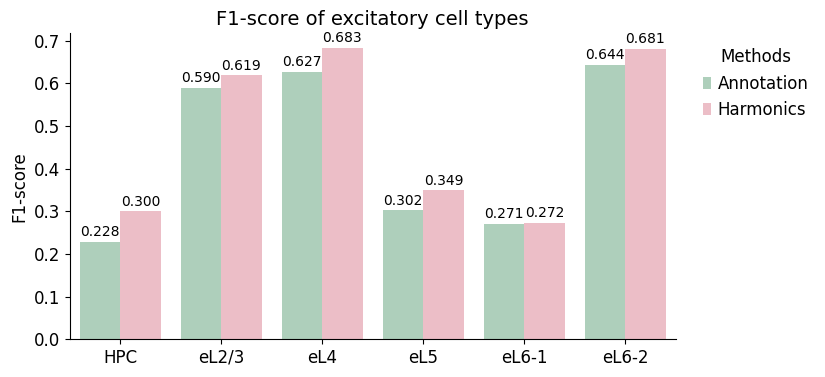

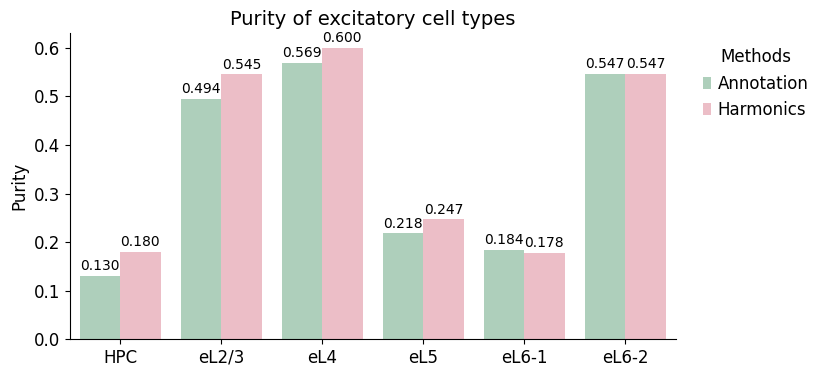

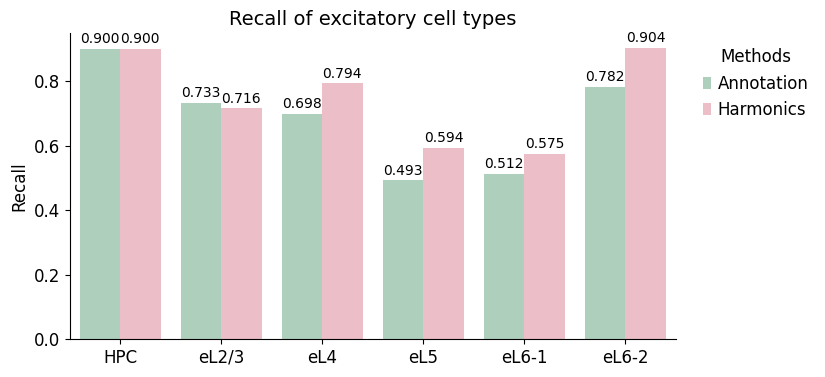

In [24]:
palette = {
    "Annotation": "#A8D5BA",   
    "Harmonics":  "#F4B6C2",   
}

score_names = ['F1-score', 'Purity', 'Recall']

for s_name in score_names:

    fig, ax = plt.subplots(figsize=(8.5, 4))

    sns.barplot(data=df, x='celltype', y=s_name, hue='Method', palette=palette, width=0.8, ax=ax)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_title(f'{s_name} of excitatory cell types', fontsize=14)
    ax.set_xlabel('', fontsize=12)
    ax.set_ylabel(s_name, fontsize=12)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(False)

    leg = ax.legend(title='Methods', fontsize=12, title_fontsize=12, frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1.0))

    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if np.isnan(height):
                continue
            ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0, 2), textcoords='offset points',
                        ha='center', va='bottom', fontsize=10, color='black')

    plt.tight_layout()
    plt.show()

#### Laminar depth axis

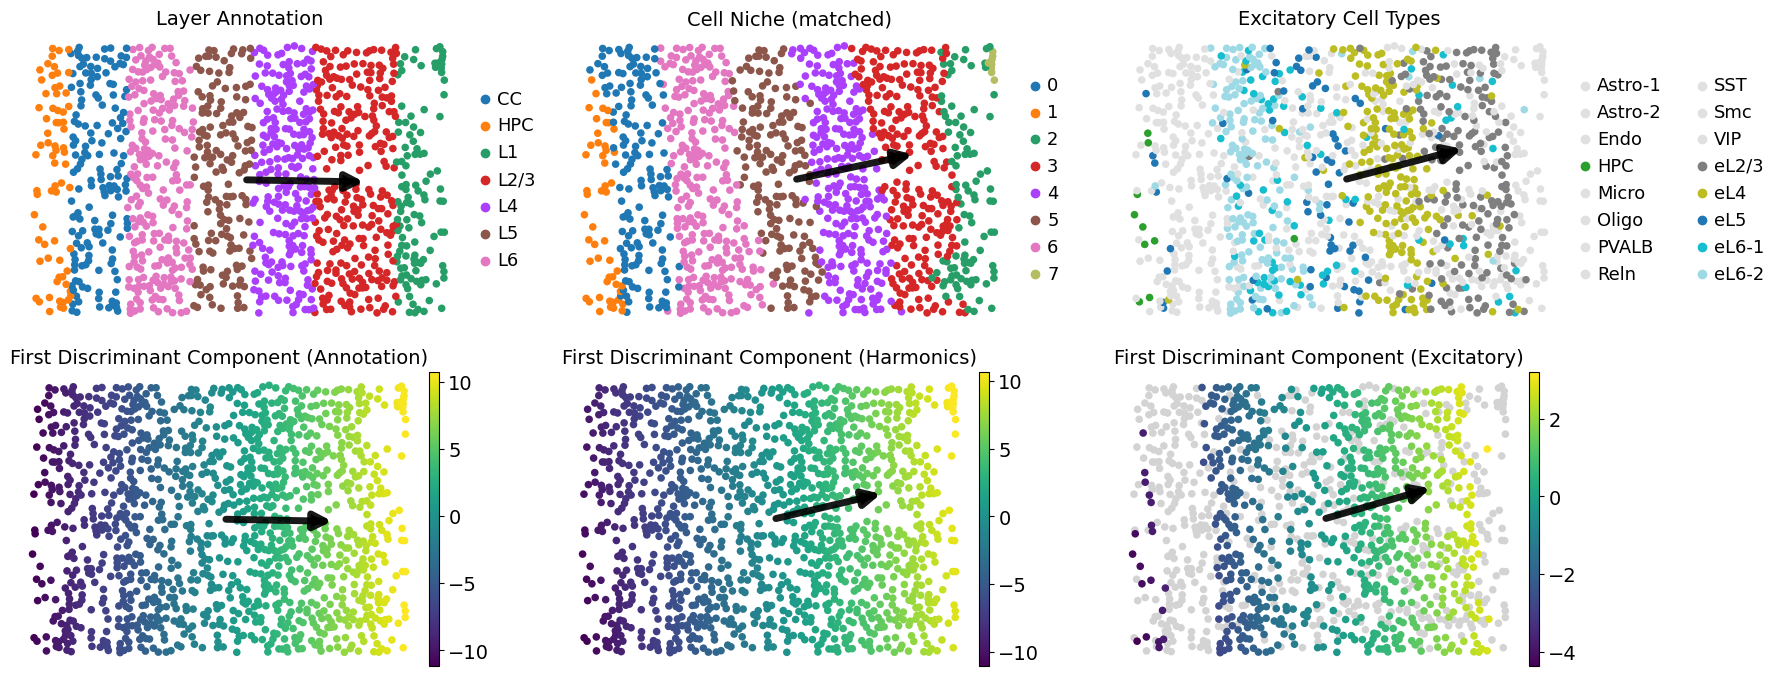

In [25]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from matplotlib.patches import FancyArrowPatch


def lda_direction_from_cells(adata, label_key, basis="spatial", solver="svd", shrinkage=None):

    X = np.asarray(adata.obsm[basis], dtype=float)          
    y = adata.obs[label_key].astype(str).values

    lda = LinearDiscriminantAnalysis(solver=solver, shrinkage=shrinkage)
    Z = lda.fit_transform(X, y)

    z1 = Z[:, 0]
    Xc = X - X.mean(axis=0)
    z1c = z1 - z1.mean()

    w = np.linalg.pinv(Xc) @ z1c
    w = w / np.linalg.norm(w)

    if np.corrcoef(Xc @ w, z1c)[0, 1] < 0:
        w = -w

    return Z, w


def add_direction_arrow(ax, origin, direction, auto=False, coords=None, frac=None, length=1., arrowstyle='-|>', lw=3.0, 
                        color="black", alpha=0.9, mutation_scale=20, eps=1e-10, zorder=10, 
                        label=None, offset=(0., 0.), fontsize=12, ha='center', va='center'):
    if auto:
        coords = np.asarray(coords)
        span = max(np.ptp(coords, axis=0))
        L = frac * span
    else:
        L = length

    direction = np.asarray(direction, float)
    direction = direction / (np.linalg.norm(direction) + eps)

    start = origin
    end = origin + L * direction

    arrow = FancyArrowPatch(
        posA=start,
        posB=end,
        arrowstyle=arrowstyle,
        linewidth=lw,
        color=color,
        alpha=alpha,
        mutation_scale=mutation_scale,
        zorder=zorder,
    )
    ax.add_patch(arrow)

    if label is not None:
        ax.text(
            end[0]+offset[0], 
            end[1]+offset[1], 
            label,
            fontsize=fontsize,
            ha=ha,
            va=va,
            color=color,
            zorder=zorder,
        )

adata_excitatory = adata[adata.obs['celltype'].isin(excitatory_cts)].copy()
adata_excitatory.obs['ct_form_different_layer']= ['eL6' if ct in ['eL6-1', 'eL6-2'] else ct for ct in adata_excitatory.obs['celltype']]

coords = adata.obsm['spatial'].copy()
origin = coords.mean(axis=0)

Z_anno, w_anno = lda_direction_from_cells(adata, 'layer', basis='spatial')
Z_Harminics, w_Harminics = lda_direction_from_cells(adata, 'matched_cluster', basis='spatial')
Z_ect, w_ect = lda_direction_from_cells(adata_excitatory, 'ct_form_different_layer', basis='spatial')

adata.obs["ld1_anno"] = Z_anno[:, 0]
adata.obs["ld1_Harmonics"] = Z_Harminics[:, 0]
adata.obs['ld1_ect'] = np.nan
adata.obs.loc[adata_excitatory.obs_names, 'ld1_ect'] = Z_ect[:, 0]

ect_color_dict = {ct: (ct_color_dict[ct] if ct in excitatory_cts else "#E0E0E0") for ct in celltypes}


fig, axes = plt.subplots(2, 3, figsize=(18, 7))

sc.pl.embedding(adata, basis='spatial', palette=layer_color_dict, color='layer', 
                ax=axes[0, 0], s=120, show=False, frameon=False, title="Layer Annotation")
add_direction_arrow(axes[0, 0], origin, w_anno, auto=True, coords=coords, frac=0.3, lw=5, mutation_scale=25)

sc.pl.embedding(adata, basis='spatial', palette=niche_color_dict, color='matched_cluster', 
                ax=axes[0, 1], s=120, show=False, frameon=False, title="Cell Niche (matched)")
add_direction_arrow(axes[0, 1], origin, w_Harminics, auto=True, coords=coords, frac=0.3, lw=5, mutation_scale=25)

sc.pl.embedding(adata, basis='spatial', palette=ect_color_dict, color='celltype', 
                ax=axes[0, 2], s=120, show=False, frameon=False, title="Excitatory Cell Types")
add_direction_arrow(axes[0, 2], origin, w_ect, auto=True, coords=coords, frac=0.3, lw=5, mutation_scale=25)

sc.pl.embedding(adata, basis='spatial', color="ld1_anno", palette="viridis",
                ax=axes[1, 0], s=120, show=False, frameon=False, title="First Discriminant Component (Annotation)")
add_direction_arrow(axes[1, 0], origin, w_anno, auto=True, coords=coords, frac=0.3, lw=5, mutation_scale=25)

sc.pl.embedding(adata, basis='spatial', color="ld1_Harmonics", palette="viridis",
                ax=axes[1, 1], s=120, show=False, frameon=False, title="First Discriminant Component (Harmonics)")
add_direction_arrow(axes[1, 1], origin, w_Harminics, auto=True, coords=coords, frac=0.3, lw=5, mutation_scale=25)

sc.pl.embedding(adata, basis='spatial', color="ld1_ect", palette="viridis",
                ax=axes[1, 2], s=120, show=False, frameon=False, title="First Discriminant Component (Excitatory)")
add_direction_arrow(axes[1, 2], origin, w_ect, auto=True, coords=coords, frac=0.3, lw=5, mutation_scale=25)

# for ax in axes.flatten():
#     ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

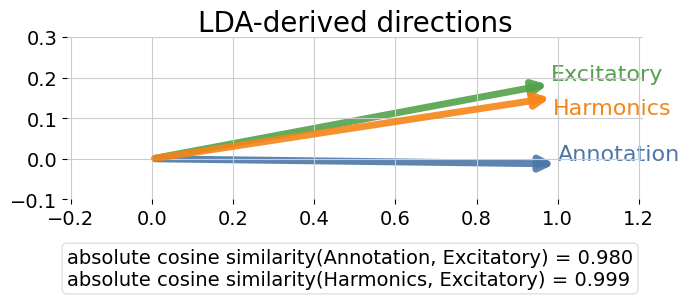

In [26]:
def unit(v):
    v = np.asarray(v, float).ravel()
    return v / np.linalg.norm(v)

def cosine_abs(a, b):
    a = unit(a)
    b = unit(b)
    return float(abs(a @ b))

arrow_colors = {
    "Excitatory": "#54A24B",   
    "Annotation": "#4C78A8",   
    "Harmonics":  "#F58518",   
}

fig, ax = plt.subplots(figsize=(7, 6))

origin = np.array([0., 0.])

L = 1.

cos_anno = cosine_abs(w_anno, w_ect)
cos_Harmonics = cosine_abs(w_Harminics, w_ect)

add_direction_arrow(ax, origin, w_ect, length=L, lw=5.0, mutation_scale=20, color=arrow_colors['Excitatory'], zorder=0, 
                    label='Excitatory', offset=(0., 0.), fontsize=16, ha='left', va='bottom')
add_direction_arrow(ax, origin, w_anno, length=L, lw=5.0, mutation_scale=20, color=arrow_colors['Annotation'], zorder=1,
                    label='Annotation', offset=(0., 0.), fontsize=16, ha='left', va='bottom')
add_direction_arrow(ax, origin, w_Harminics, length=L, lw=5.0, mutation_scale=20, color=arrow_colors['Harmonics'], zorder=2,
                    label='Harmonics', offset=(0., -0.05), fontsize=16, ha='left', va='bottom')

ax.text(
    0, -0.3, 
    f"absolute cosine similarity(Annotation, Excitatory) = {cos_anno:.3f}\n"
    f"absolute cosine similarity(Harmonics, Excitatory) = {cos_Harmonics:.3f}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14,
    color="black",
    bbox=dict(
        facecolor="white",
        edgecolor="#DDDDDD",
        alpha=0.9,
        boxstyle="round,pad=0.25"
    )
)

ax.set_xlim(origin[0] - 0.21 * L, origin[0] + 1.21 * L)
ax.set_ylim(origin[1] - 0.1 * L, origin[1] + 0.3 * L)

ax.set_aspect("equal", adjustable="box")
# ax.set_xticks([])
# ax.set_yticks([])
for s in ["top", "right", "left", "bottom"]:
    ax.spines[s].set_visible(False)

ax.set_title("LDA-derived directions", fontsize=20, pad=0)

plt.tight_layout()
plt.show()

In [27]:
def fisher_ratio_multiclass(z, y, classes=None, eps=1e-10):
    z = np.asarray(z, float).ravel()
    y = np.asarray(y)

    if classes is None:
        classes = np.unique(y)

    mask = np.isin(y, classes)
    z = z[mask]
    y = y[mask]

    mu = z.mean()
    SB = 0.0
    SW = 0.0

    for c in classes:
        zc = z[y == c]
        if zc.size == 0:
            continue
        muk = zc.mean()
        SB += zc.size * (muk - mu) ** 2
        SW += np.sum((zc - muk) ** 2)

    return SB / (SW + eps)

niche_related_cts = ['eL6' if ct in ['eL6-1', 'eL6-2'] else ct for ct in adata.obs['celltype']]
fisher_anno = fisher_ratio_multiclass(adata.obs['ld1_anno'], niche_related_cts, classes=['HPC', 'eL2/3', 'eL4', 'eL5', 'eL6'])
fisher_Harmonics = fisher_ratio_multiclass(adata.obs['ld1_Harmonics'], niche_related_cts, classes=excitatory_cts)
fisher_anno, fisher_Harmonics

(np.float64(2.0140179901864137), np.float64(2.259881480507602))

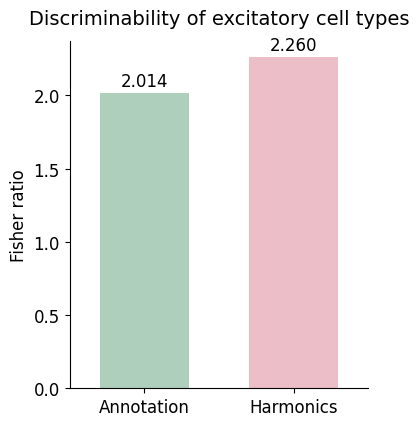

In [28]:
df_fisher = pd.DataFrame({
    'Method': ['Annotation', 'Harmonics'],
    'Fisher ratio': [fisher_anno, fisher_Harmonics]
})

fig, ax = plt.subplots(figsize=(4, 4.5))

sns.barplot(data=df_fisher, x='Method', y='Fisher ratio', palette=palette, width=0.6, ax=ax)

ax.set_title('Discriminability of excitatory cell types', fontsize=14, pad=12)
ax.set_xlabel('', fontsize=12)
ax.set_ylabel('Fisher ratio', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(False)

# ymax = df_fisher['Fisher ratio'].max()
# ax.set_ylim(0, ymax * 1.1)

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if np.isnan(height):
            continue
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0, 2), textcoords='offset points',
                    ha='center', va='bottom', fontsize=12, color='black')

plt.tight_layout()
plt.show()

#### Differential expression analysis and marker concentration

In [29]:
adata_copy = adata.copy()
sc.pp.normalize_total(adata_copy, target_sum=1e4)
sc.pp.log1p(adata_copy)

sc.tl.pca(adata_copy, n_comps=10, random_state=1234)
sc.pp.neighbors(adata_copy, n_neighbors=15, n_pcs=10, random_state=1234)
sc.tl.umap(adata_copy, random_state=1234, min_dist=0.1)

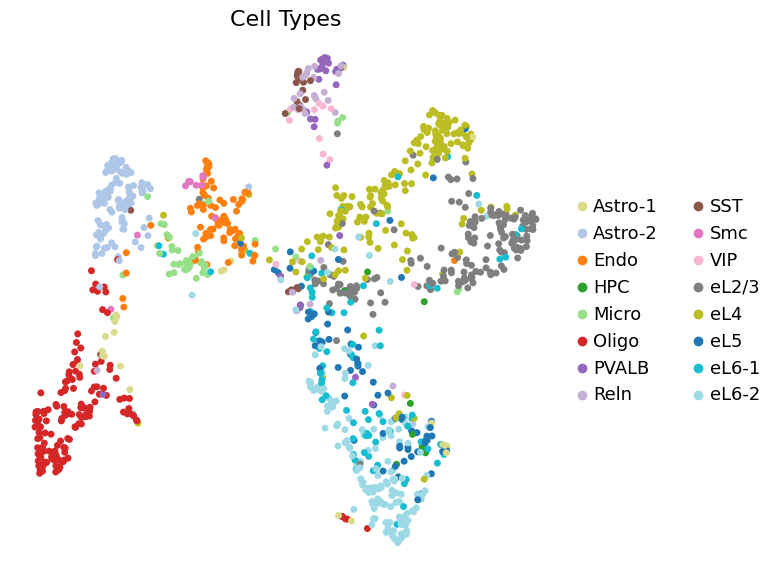

In [30]:
fig, ax = plt.subplots(figsize=(8,6))

sc.pl.umap(adata_copy, color='celltype', palette=ct_color_dict, s=100, frameon=False, 
           title='Cell Types', ax=ax, show=False)
plt.title('Cell Types', fontsize=16)

plt.tight_layout()
plt.show()

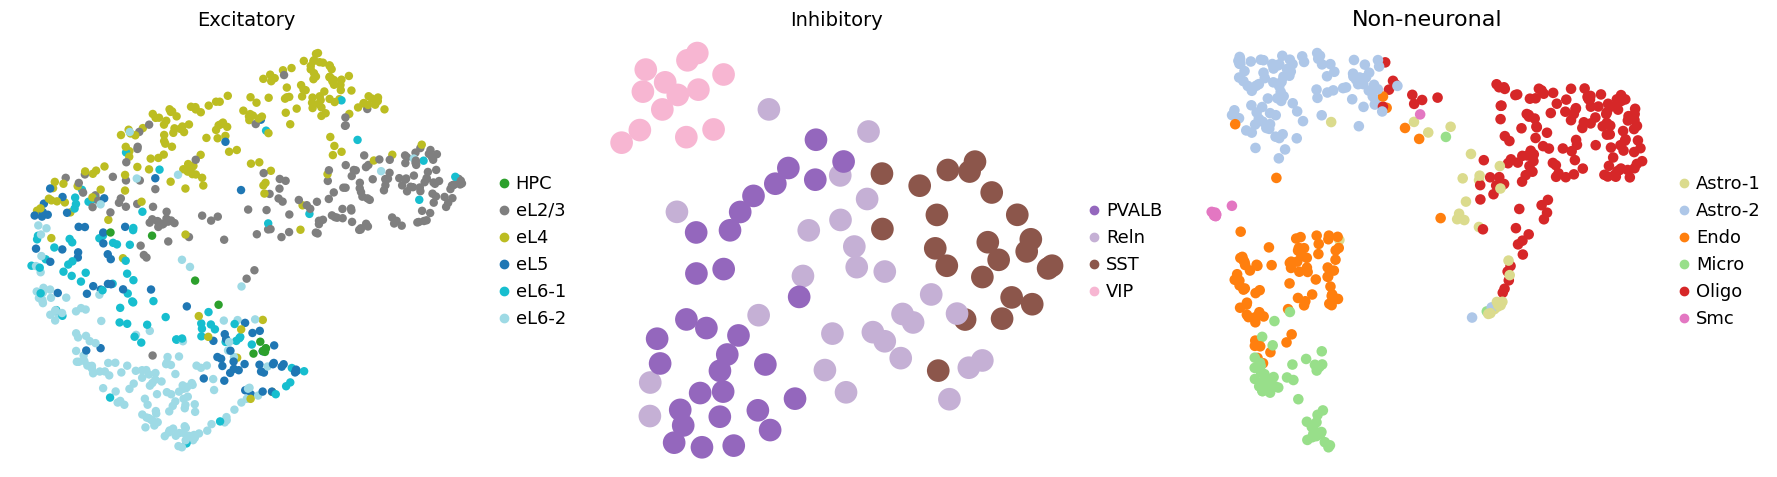

In [31]:
major_categories_dict = {
    'Excitatory': excitatory_cts,
    'Inhibitory': inhibitory_cts, 
    'Non-neuronal': nn_cts,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, cat in enumerate(major_categories_dict.keys()):

    adata_sub = adata[adata.obs['celltype'].isin(major_categories_dict[cat])].copy()
    n_cells = adata_sub.shape[0]
    s = 1e5/n_cells

    sc.pp.normalize_total(adata_sub, target_sum=1e4)
    sc.pp.log1p(adata_sub)

    sc.tl.pca(adata_sub, n_comps=10, random_state=1234)
    sc.pp.neighbors(adata_sub, n_neighbors=15, n_pcs=10, random_state=1234)
    sc.tl.umap(adata_sub, random_state=1234, min_dist=0.1)

    sc.pl.umap(adata_sub, color='celltype', palette=ct_color_dict, s=s, frameon=False, 
               title=cat, ax=axes[i], show=False)
    plt.title(cat, fontsize=16)

plt.tight_layout()
plt.show()

In [32]:
adata_excitatory = adata[adata.obs['celltype'].isin(excitatory_cts)].copy()
# adata_excitatory = adata_excitatory[adata_excitatory.obs['celltype'] != 'HPC'].copy()
sc.pp.normalize_total(adata_excitatory, target_sum=1e4)
sc.pp.log1p(adata_excitatory)
adata_excitatory

AnnData object with n_obs × n_vars = 680 × 1020
    obs: 'clusterid', 'celltype', 'layer', 'slice_name', 'celltype_idx', 'n_neighbors', 'niche_label_jsd', 'niche_label_jsd_v2', 'niche_label_fmi', 'niche_label_ari', 'niche_label_nmi', 'niche_label_asw', 'niche_label_js_asw', 'niche_label_fisher', 'niche_label_chi', 'niche_label_dbi', 'niche_label_dass_min', 'niche_label_dass_mean', 'niche_label_dafisher', 'niche_label_dachi', 'niche_label_0.09', 'niche_label_0.11', 'niche_label_9', 'niche_label_8', 'niche_label_7', 'niche_label_6', 'niche_label_5', 'niche_label_4', 'niche_label_3', 'niche_label_2', 'niche_label', 'matched_cluster', 'matched_label', 'ld1_anno', 'ld1_Harmonics', 'ld1_ect'
    uns: 'ct2idx', 'idx2ct', 'niche_cell_count', 'niche_dist', 'niche_label_summary', 'score_dict', 'layer_colors', 'matched_cluster_colors', 'niche_label_colors', 'celltype_colors', 'log1p'
    obsm: 'micro_dist', 'onehot', 'spatial'
    obsp: 'delaunay_adj_mtx'

In [33]:
df_layer_ct = pd.crosstab(
    adata_excitatory.obs["layer"],
    adata_excitatory.obs["celltype"]
)

df_niche_ct = pd.crosstab(
    adata_excitatory.obs["matched_cluster"],
    adata_excitatory.obs["celltype"]
)

df_layer_ct, df_niche_ct

(celltype  HPC  eL2/3  eL4  eL5  eL6-1  eL6-2
 layer                                       
 CC          0      0    0    2      2     15
 HPC         9      0    1    8      0      1
 L1          0     32    2    0      4      1
 L2/3        0    129   38    3     13      2
 L4          0     13  132   12      6      2
 L5          1      0   14   34     14     13
 L6          0      2    2   10     41    122,
 celltype         HPC  eL2/3  eL4  eL5  eL6-1  eL6-2
 matched_cluster                                    
 0                  0      0    0    1      0      2
 1                  9      0    1    7      0      1
 2                  0     25    2    0      2      2
 3                  0    126   19    2     15      3
 4                  0     23  150    5      5      1
 5                  0      0   14   41     12      6
 6                  1      2    3   13     46    141)

In [34]:
def volcano_plot_per_group(
    adata, 
    key="rank_genes_groups", 
    groups=None, 
    qvals_thres=0.05, 
    logfc_thres=0.2,
    max_labels=10,
    point_size=20,
    alpha=0.9,
    cmap_other="#BDBDBD",
    color_sig="#D62728",
    fontsize=12,
    title_fontsize=12,
    label_fontsize=12,
    tick_fontsize=12,
):
    try:
        from adjustText import adjust_text
        has_adjust = True
    except Exception:
        has_adjust = False

    if groups is None:
        groups = list(adata.obs[adata.uns[key]["params"]["groupby"]].astype(str).unique())
    
    n_groups = len(groups)
    fig, axes = plt.subplots(int(np.ceil(n_groups/4)), 4, figsize=(20, 4 * np.ceil(n_groups/4)))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes.flatten()[n_groups:]:
        ax.axis('off')

    for i, g in enumerate(groups):

        df = sc.get.rank_genes_groups_df(adata, group=g, key=key).copy()
        df = df.dropna(subset=["names", "pvals_adj", "logfoldchanges"])
        df["qval"] = df["pvals_adj"].astype(float)

        eps = 1e-300
        df["-log10q"] = -np.log10(np.clip(df["qval"].to_numpy(), eps, None))
        df["logfc"] = df["logfoldchanges"].astype(float)

        sig_up = (df["qval"] < qvals_thres) & (df["logfc"] > logfc_thres)

        axes[i].scatter(df.loc[~sig_up, "logfc"], df.loc[~sig_up, "-log10q"], s=point_size, 
                   alpha=alpha, c=cmap_other, linewidths=0, rasterized=True,)

        axes[i].scatter(df.loc[sig_up, "logfc"], df.loc[sig_up, "-log10q"], s=point_size,
                   alpha=0.9, c=color_sig, linewidths=0, rasterized=True,)

        axes[i].axvline(logfc_thres, ls="--", lw=1.0, c="#666666")
        axes[i].axhline(-np.log10(qvals_thres), ls="--", lw=1.0, c="#666666")

        df_sig = df.loc[sig_up].copy()
        if max_labels is not None and df_sig.shape[0] > max_labels:
            df_sig = df_sig.sort_values("qval", ascending=True).head(max_labels)

        texts = []
        for _, r in df_sig.iterrows():
            t = axes[i].text(r["logfc"], r["-log10q"], str(r["names"]), fontsize=fontsize, color=color_sig, ha="left", va="bottom")
            texts.append(t)

        if has_adjust and len(texts) > 0:
            adjust_text(
                texts,
                ax=axes[i],
                arrowprops=dict(arrowstyle="-", color="#888888", lw=1., alpha=0.8),
                expand_points=(1.2, 1.4),
                expand_text=(1.2, 1.4),
                force_text=(0.2, 0.4),
            )

        axes[i].set_title(f"Volcano plot: {g}", fontsize=title_fontsize, pad=10)
        axes[i].set_xlabel("log fold change", fontsize=label_fontsize)
        axes[i].set_ylabel("-log10(q value)", fontsize=label_fontsize)
        axes[i].tick_params(axis='x', labelsize=tick_fontsize)
        axes[i].tick_params(axis='y', labelsize=tick_fontsize)
        axes[i].spines["top"].set_visible(False)
        axes[i].spines["right"].set_visible(False)
        axes[i].grid(False)

    plt.tight_layout()
    plt.show()

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


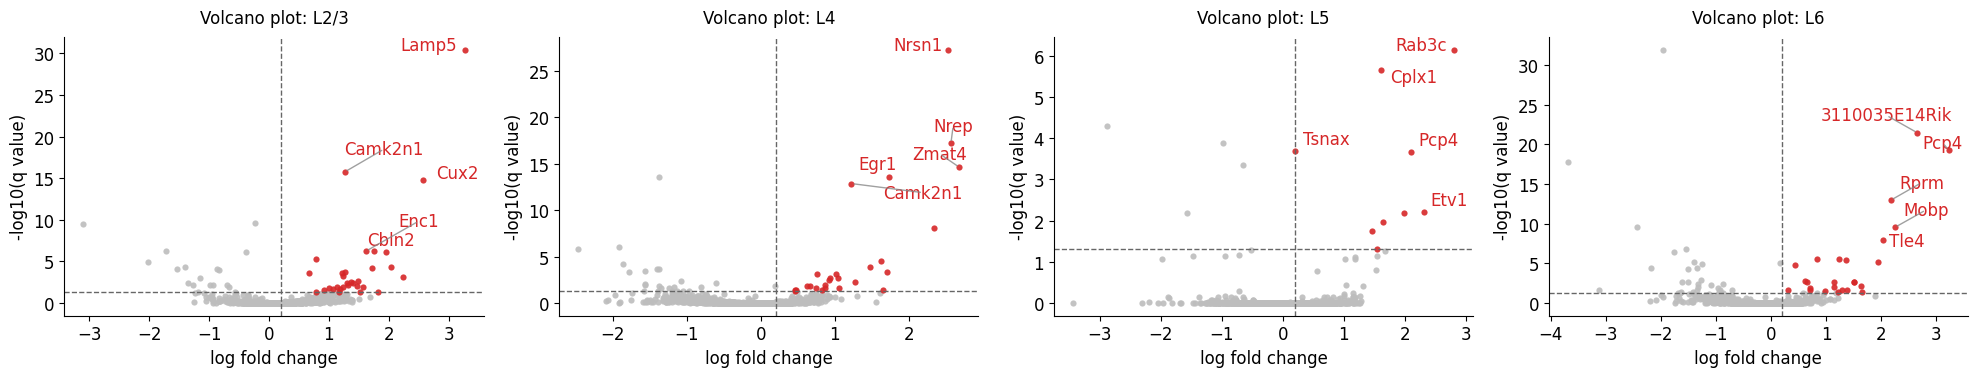

In [35]:
adata_ex_anno = adata_excitatory.copy()
sc.tl.rank_genes_groups(adata_ex_anno, 
                        groupby="layer", 
                        method="wilcoxon", 
                        groups=['L2/3', 'L4', 'L5', 'L6'], 
                        use_raw=False, 
                        pts=True,
                        )

volcano_plot_per_group(
    adata_ex_anno,
    key="rank_genes_groups",
    groups=['L2/3', 'L4', 'L5', 'L6'],           
    qvals_thres=0.05,
    logfc_thres=0.2,
    max_labels=5,
)         

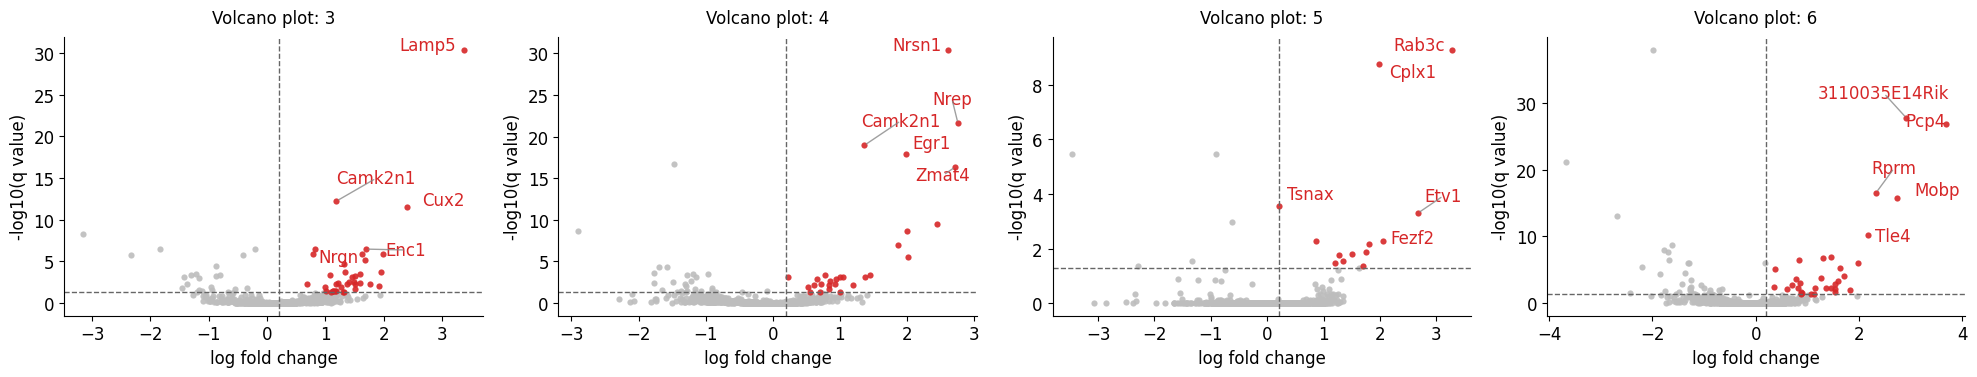

In [36]:
adata_ex_Harmonics = adata_excitatory.copy()
sc.tl.rank_genes_groups(adata_ex_Harmonics, 
                        groupby="matched_cluster", 
                        method="wilcoxon", 
                        groups=['3', '4', '5', '6'], 
                        use_raw=False, 
                        pts=True,
                        )

volcano_plot_per_group(
    adata_ex_Harmonics,
    key="rank_genes_groups",
    groups=['3', '4', '5', '6'],           
    qvals_thres=0.05,
    logfc_thres=0.2,
    max_labels=5,
)         

In [37]:
for g in ['3', '4', '5', '6']:
    df = sc.get.rank_genes_groups_df(adata_ex_Harmonics, group=g, key="rank_genes_groups").copy()
    sig = df[(df["pvals_adj"] < 0.05) & (df["logfoldchanges"] > 0.2)]

    print(f"\n===== Niche {g} =====")
    print(f"Significant upregulated genes: {sig.shape[0]}")
    for name in sig["names"].tolist():
        print(f"- {name}")


===== Niche 3 =====
Significant upregulated genes: 37
- Lamp5
- Camk2n1
- Cux2
- Enc1
- Nrgn
- Cpne5
- Pcsk2
- 2900055J20Rik
- Cbln2
- Camk2a
- Gucy1b3
- Calb1
- Nectin3
- Ncdn
- Cacng3
- Enpp2
- Lrrtm4
- Acvr1c
- Gria3
- Nell2
- Hpcal4
- B230216N24Rik
- Btbd11
- Atp2b4
- Cenpw
- Ddit4l
- Hhatl
- Atp6ap1l
- Chodl
- Ttyh1
- Cd34
- Hpca
- 1700086L19Rik
- Pdzrn3
- 6330403K07Rik
- Gpr151
- Trp53i11

===== Niche 4 =====
Significant upregulated genes: 28
- Nrsn1
- Nrep
- Camk2n1
- Egr1
- Zmat4
- Whrn
- Cux2
- Nudt4
- Rorb
- Arpp21
- Btbd3
- Aldoc
- Nrn1
- Fos
- Ralyl
- Bcl6
- Nell1
- Mef2c
- Epha4
- Arc
- Atp1a2
- Fam19a2
- Dusp6
- Hlf
- Egr3
- Cadps2
- Gpm6b
- Hmgcr

===== Niche 5 =====
Significant upregulated genes: 13
- Rab3c
- Cplx1
- Tsnax
- Etv1
- Fezf2
- Pgm2l1
- Pcp4
- Tmsb10
- Efr3a
- Slc20a1
- Acot13
- Rap1gds1
- Sulf2

===== Niche 6 =====
Significant upregulated genes: 32
- 3110035E14Rik
- Pcp4
- Rprm
- Mobp
- Tle4
- Ogfrl1
- Nptx1
- Hpcal4
- Arhgap25
- Mbp
- Scg2
- Col6a1
- Klf1

In [38]:
def get_logfc_and_qval_for_gene(adata, key, group, gene):
    df = sc.get.rank_genes_groups_df(adata, group=group, key=key)
    row = df[df["names"] == gene]
    if row.shape[0] == 0:
        return None
    return float(row["logfoldchanges"].iloc[0]), float(row["pvals_adj"].iloc[0])

layer_marker = {
    'L2/3': ['Enpp2', 'Cpne5'],
    'L4': ['Rorb', 'Whrn', 'Btbd3', 'Nrep', 'Zmat4'],
    'L5': ['Etv1', 'Fezf2', 'Cplx1'],
    'L6': ['Rprm', 'Plcxd3', 'Pcp4', 'Tle4'],
}

layer_to_niche = {
    'L2/3': '3',
    'L4': '4',
    'L5': '5',
    'L6': '6',
}

for layer, markers in layer_marker.items():
    niche = layer_to_niche[layer]
    g_list = []
    for gene in markers:
        logfc_anno, q_anno = get_logfc_and_qval_for_gene(adata_ex_anno, key="rank_genes_groups", group=layer, gene=gene)
        logfc_Harmonics, q_Harmonics = get_logfc_and_qval_for_gene(adata_ex_Harmonics, key="rank_genes_groups", group=niche, gene=gene)

        print(f"{gene} in {layer}/Niche{niche} -> Annotation logFC: {logfc_anno}, q-value: {q_anno}, significant: {q_anno < 0.05}")
        print(f"{gene} in {layer}/Niche{niche} -> Harmonics logFC: {logfc_Harmonics}, q-value: {q_Harmonics}, significant: {q_Harmonics < 0.05}\n")

Enpp2 in L2/3/Niche3 -> Annotation logFC: 1.2986679077148438, q-value: 0.0036319776841205543, significant: True
Enpp2 in L2/3/Niche3 -> Harmonics logFC: 1.4527212381362915, q-value: 0.0007232070477109227, significant: True

Cpne5 in L2/3/Niche3 -> Annotation logFC: 1.9511423110961914, q-value: 7.355318067377369e-07, significant: True
Cpne5 in L2/3/Niche3 -> Harmonics logFC: 1.98761785030365, q-value: 1.3100156715311015e-06, significant: True

Rorb in L4/Niche4 -> Annotation logFC: 1.7043458223342896, q-value: 0.00041602235784925034, significant: True
Rorb in L4/Niche4 -> Harmonics logFC: 2.019033432006836, q-value: 2.571163061879567e-06, significant: True

Whrn in L4/Niche4 -> Annotation logFC: 2.333984136581421, q-value: 8.94273886808038e-09, significant: True
Whrn in L4/Niche4 -> Harmonics logFC: 2.451214551925659, q-value: 2.8196421302645644e-10, significant: True

Btbd3 in L4/Niche4 -> Annotation logFC: 1.2737557888031006, q-value: 0.006084667639178409, significant: True
Btbd3 in L

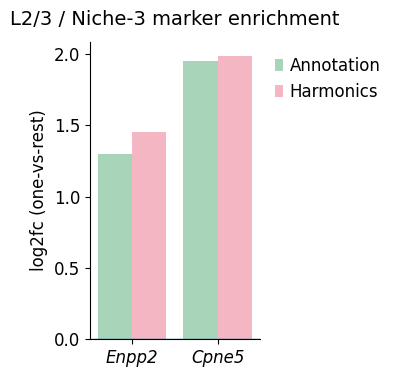

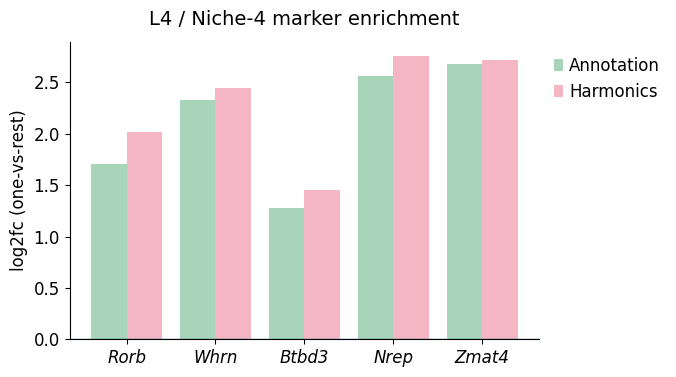

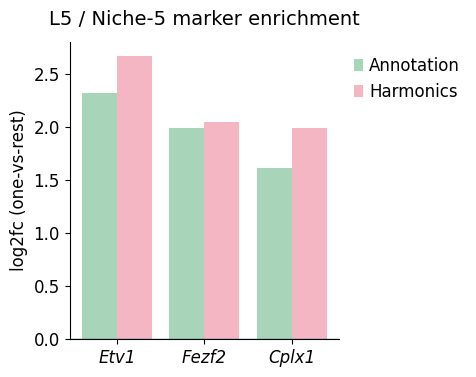

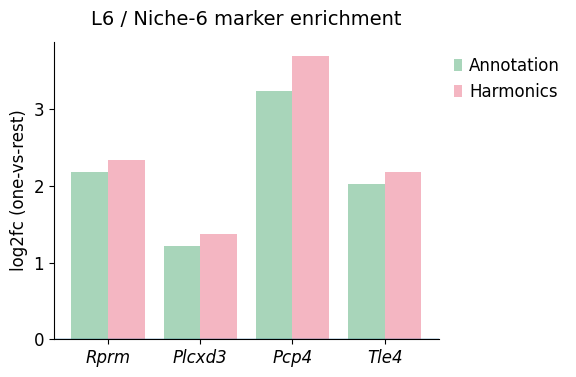

In [39]:
for layer, genes in layer_marker.items():
    niche = layer_to_niche[layer]
    genes = list(genes)

    logfc_anno, q_anno = [], []
    logfc_har, q_har = [], []

    for g in genes:
        lf1, q1 = get_logfc_and_qval_for_gene(adata_ex_anno, key='rank_genes_groups', group=layer, gene=g)
        lf2, q2 = get_logfc_and_qval_for_gene(adata_ex_Harmonics, key='rank_genes_groups', group=niche, gene=g)
        logfc_anno.append(lf1); q_anno.append(q1)
        logfc_har.append(lf2);  q_har.append(q2)

    x = np.arange(len(genes))
    width = 0.4

    plt.figure(figsize=(2 + 1 * len(genes), 4))

    bars1 = plt.bar(x - width/2, logfc_anno, width, label=f"Annotation", color="#A8D5BA")
    bars2 = plt.bar(x + width/2, logfc_har,  width, label=f"Harmonics", color="#F4B6C2")

    for b, qv in zip(bars1, q_anno):
        if qv > 0.05:
            b.set_hatch("///")
    for b, qv in zip(bars2, q_har):
        if qv > 0.05:
            b.set_hatch("///")

    plt.axhline(0, linewidth=1)

    plt.xticks(x, genes, rotation=0, ha="center", fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylabel("log2fc (one-vs-rest)", fontsize=12)
    plt.title(f"{layer} / Niche-{niche} marker enrichment", pad=12, fontsize=14)
    plt.legend(frameon=False, fontsize=12, bbox_to_anchor=(1.0, 1.0), loc='upper left')

    ax = plt.gca()
    for label in ax.get_xticklabels():
        label.set_fontstyle("italic")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    plt.tight_layout()
    plt.show()